# Molecular Feature Difficulty Analysis — Per Experiment
Explores which molecular features make test-set compounds harder to predict (i.e., not found in the top-10 predictions).  
Each experiment is analysed independently — the test sets overlap so concatenating them would bias results.  
Uses ATMoMACC v5 fingerprints, standard MACCS keys, and RDKit molecular descriptors, then K-means clusters each test set.

In [11]:
import sys, os, warnings, pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from rdkit.Chem.Draw import IPythonConsole
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats

sys.path.insert(0, '../src')
from ATMOMACCS_no_binary import pyGenATMOKeys, pyGenATMOMACCS, pyGenMACCSKeys
from src.metrics.diffms_metrics import K_ACC_Collection
from src.utils import is_valid

RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
IPythonConsole.molSize = (350, 350)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
EXP_BASE = 'data/new_experiments'
print('Setup complete.')

Setup complete.


## 1. Load experiment predictions

In [12]:
def load_exp(exp_dir, pred_prefix='dev_pred', true_prefix='dev_true'):
    """Load all pred/true pkl shards from an experiment directory."""
    pred_files = sorted(
        [f for f in os.listdir(exp_dir) if f.startswith(pred_prefix) and f.endswith('.pkl')],
        key=lambda f: int(f.split('_')[-1].replace('.pkl', ''))
    )
    all_preds, all_trues = [], []
    for pf in pred_files:
        tf = pf.replace(pred_prefix, true_prefix)
        with open(os.path.join(exp_dir, pf), 'rb') as fh:
            all_preds.extend(pkl.load(fh))
        with open(os.path.join(exp_dir, tf), 'rb') as fh:
            all_trues.extend(pkl.load(fh))
    return all_preds, all_trues

# Load each experiment into its own list of records
EXP_CONFIGS = {
    'exp1': dict(exp_dir=f'{EXP_BASE}/exp1'),
    'exp2': dict(exp_dir=f'{EXP_BASE}/exp2', pred_prefix='dev_resume_pred', true_prefix='dev_resume_true'),
    'exp3': dict(exp_dir=f'{EXP_BASE}/exp3'),
}

experiments_records = {}
for exp_name, cfg in EXP_CONFIGS.items():
    preds, trues = load_exp(**cfg)
    experiments_records[exp_name] = [{'true_mol': t, 'pred_mols': p} for p, t in zip(preds, trues)]
    print(f'{exp_name}: {len(preds)} molecules')

exp1: 6682 molecules
exp2: 7548 molecules
exp3: 7548 molecules


In [13]:
def mol_hit_flags(pred_mols, true_mol, k_list=(1, 5, 10)):
    """
    Per-molecule hit flags using the same logic as K_ACC_Collection.update():
    filter invalid mols → convert to InChI → deduplicate by count → check membership at each k.
    """
    true_inchi = Chem.MolToInchi(true_mol)
    inchis = [Chem.MolToInchi(mol) for mol in pred_mols if is_valid(mol)]
    ranked = [inchi for inchi, _ in Counter(inchis).most_common()]
    return {k: true_inchi in ranked[:k] for k in k_list}

# Compute hit flags and canonical K_ACC_Collection accuracy per experiment
for exp_name, records in experiments_records.items():
    metric = K_ACC_Collection(k_list=[1, 5, 10])
    metric.reset()
    for r in records:
        flags = mol_hit_flags(r['pred_mols'], r['true_mol'])
        r['hit_top1']  = flags[1]
        r['hit_top5']  = flags[5]
        r['hit_top10'] = flags[10]
        metric.update(r['pred_mols'], r['true_mol'])
    results = metric.compute()
    print(f"{exp_name}:  " + "  ".join(f"{k}={v:.4f}" for k, v in results.items()))

exp1:  acc_at_1=0.0217  acc_at_5=0.0554  acc_at_10=0.0670
exp2:  acc_at_1=0.0241  acc_at_5=0.0594  acc_at_10=0.0808
exp3:  acc_at_1=0.0356  acc_at_5=0.0811  acc_at_10=0.1036


## 2. Compute molecular features

In [14]:
# Load ATMoMACC v5 feature names
atmo_names_df = pd.read_csv('explained_atmo_patterns_v5.csv', index_col=0)
maccs_names_df = pd.read_csv('explained_patterns_v5.csv', index_col=0)

atmo_feat_names = atmo_names_df['Name'].tolist()          # 38 features
maccs_feat_names = [f'MACCS_{i}' for i in range(167)]    # 167 MACCS bits
atmomaccs_feat_names = maccs_feat_names + atmo_feat_names

print(f'ATMoMACC v5 ATMO features : {len(atmo_feat_names)}')
print(f'ATMoMACC v5 MACCS features: {len(maccs_feat_names)}')
print(f'ATMoMACC v5 total         : {len(atmomaccs_feat_names)}')

ATMoMACC v5 ATMO features : 38
ATMoMACC v5 MACCS features: 167
ATMoMACC v5 total         : 205


In [18]:
DESC_KEYS = [
    'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds',
    'ArRings', 'NonArRings', 'AllRings', 'Fsp3',
    'nC', 'nO', 'nN', 'nHalogen', 'nS',
    'FormalCharge', 'HeavyAtoms',
    'O_C_ratio', 'N_C_ratio',
]

def compute_rdkit_descriptors(mol):
    """Compute a panel of interpretable RDKit molecular descriptors. Raises on failure."""
    n_ar = rdMolDescriptors.CalcNumAromaticRings(mol)
    n_r  = rdMolDescriptors.CalcNumRings(mol)
    n_c  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 6)
    n_o  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 8)
    return {
        'MW':          Descriptors.ExactMolWt(mol),
        'LogP':        Descriptors.MolLogP(mol),
        'TPSA':        rdMolDescriptors.CalcTPSA(mol),
        'HBD':         rdMolDescriptors.CalcNumHBD(mol),
        'HBA':         rdMolDescriptors.CalcNumHBA(mol),
        'RotBonds':    rdMolDescriptors.CalcNumRotatableBonds(mol),
        'ArRings':     n_ar,
        'NonArRings':  max(0, n_r - n_ar),
        'AllRings':    n_r,
        'Fsp3':        rdMolDescriptors.CalcFractionCSP3(mol),
        'nC':          n_c,
        'nO':          n_o,
        'nN':          sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7),
        'nHalogen':    sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() in (9, 17, 35, 53)),
        'nS':          sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 16),
        'FormalCharge':Chem.rdmolops.GetFormalCharge(mol),
        'HeavyAtoms':  mol.GetNumHeavyAtoms(),
        'O_C_ratio':   n_o / max(n_c, 1),
        'N_C_ratio':   sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7) / max(n_c, 1),
    }

# Compute fingerprints and descriptors per experiment
exp_fps  = {}  # {exp_name: {'atmomaccs': arr, 'atmo': arr, 'maccs': arr}}
exp_desc = {}  # {exp_name: DataFrame}

for exp_name, records in experiments_records.items():
    atmo_fps_l, maccs_fps_l, atmomaccs_fps_l, desc_rows = [], [], [], []
    failed_fp, failed_desc = [], []

    for i, r in enumerate(records):
        mol = r['true_mol']

        try:
            atmo_fp  = pyGenATMOKeys(mol)
            maccs_fp = np.array(list(pyGenMACCSKeys(mol)), dtype=np.uint8)
            combined = np.concatenate([maccs_fp, atmo_fp])
        except Exception as e:
            failed_fp.append(i)
            print(f'[{exp_name}][fp   ] record {i}: {type(e).__name__}: {e}')
            atmo_fp  = np.zeros(38,  dtype=np.uint8)
            maccs_fp = np.zeros(167, dtype=np.uint8)
            combined = np.zeros(205, dtype=np.uint8)

        atmo_fps_l.append(atmo_fp)
        maccs_fps_l.append(maccs_fp)
        atmomaccs_fps_l.append(combined)

        try:
            desc_rows.append(compute_rdkit_descriptors(mol))
        except Exception as e:
            failed_desc.append(i)
            print(f'[{exp_name}][desc ] record {i}: {type(e).__name__}: {e}')
            desc_rows.append({k: np.nan for k in DESC_KEYS})

    exp_fps[exp_name]  = {
        'atmomaccs': np.array(atmomaccs_fps_l, dtype=np.float32),
        'atmo':      np.array(atmo_fps_l,      dtype=np.float32),
        'maccs':     np.array(maccs_fps_l,     dtype=np.float32),
    }
    exp_desc[exp_name] = pd.DataFrame(desc_rows)
    print(f'{exp_name}: fp failures={len(failed_fp)}, desc failures={len(failed_desc)}')

exp1: fp failures=0, desc failures=0
exp2: fp failures=0, desc failures=0
exp3: fp failures=0, desc failures=0


In [19]:
# Build one analysis DataFrame per experiment
exp_dfs = {}

for exp_name, records in experiments_records.items():
    base_df   = pd.DataFrame([{k: v for k, v in r.items() if k != 'pred_mols'} for r in records])
    atmo_df   = pd.DataFrame(exp_fps[exp_name]['atmo'], columns=atmo_feat_names)
    adf = pd.concat([
        base_df[['hit_top1', 'hit_top5', 'hit_top10']].reset_index(drop=True),
        exp_desc[exp_name].reset_index(drop=True),
        atmo_df.reset_index(drop=True),
    ], axis=1)
    exp_dfs[exp_name] = adf

    hit  = adf[adf['hit_top10']]
    miss = adf[~adf['hit_top10']]
    print(f'{exp_name}: n={len(adf):,}  hit={len(hit):,} ({len(hit)/len(adf):.3f})  miss={len(miss):,}')

exp1: n=6,682  hit=448 (0.067)  miss=6,234
exp2: n=7,548  hit=610 (0.081)  miss=6,938
exp3: n=7,548  hit=782 (0.104)  miss=6,766


## 3. Molecular descriptor distributions: hit vs miss

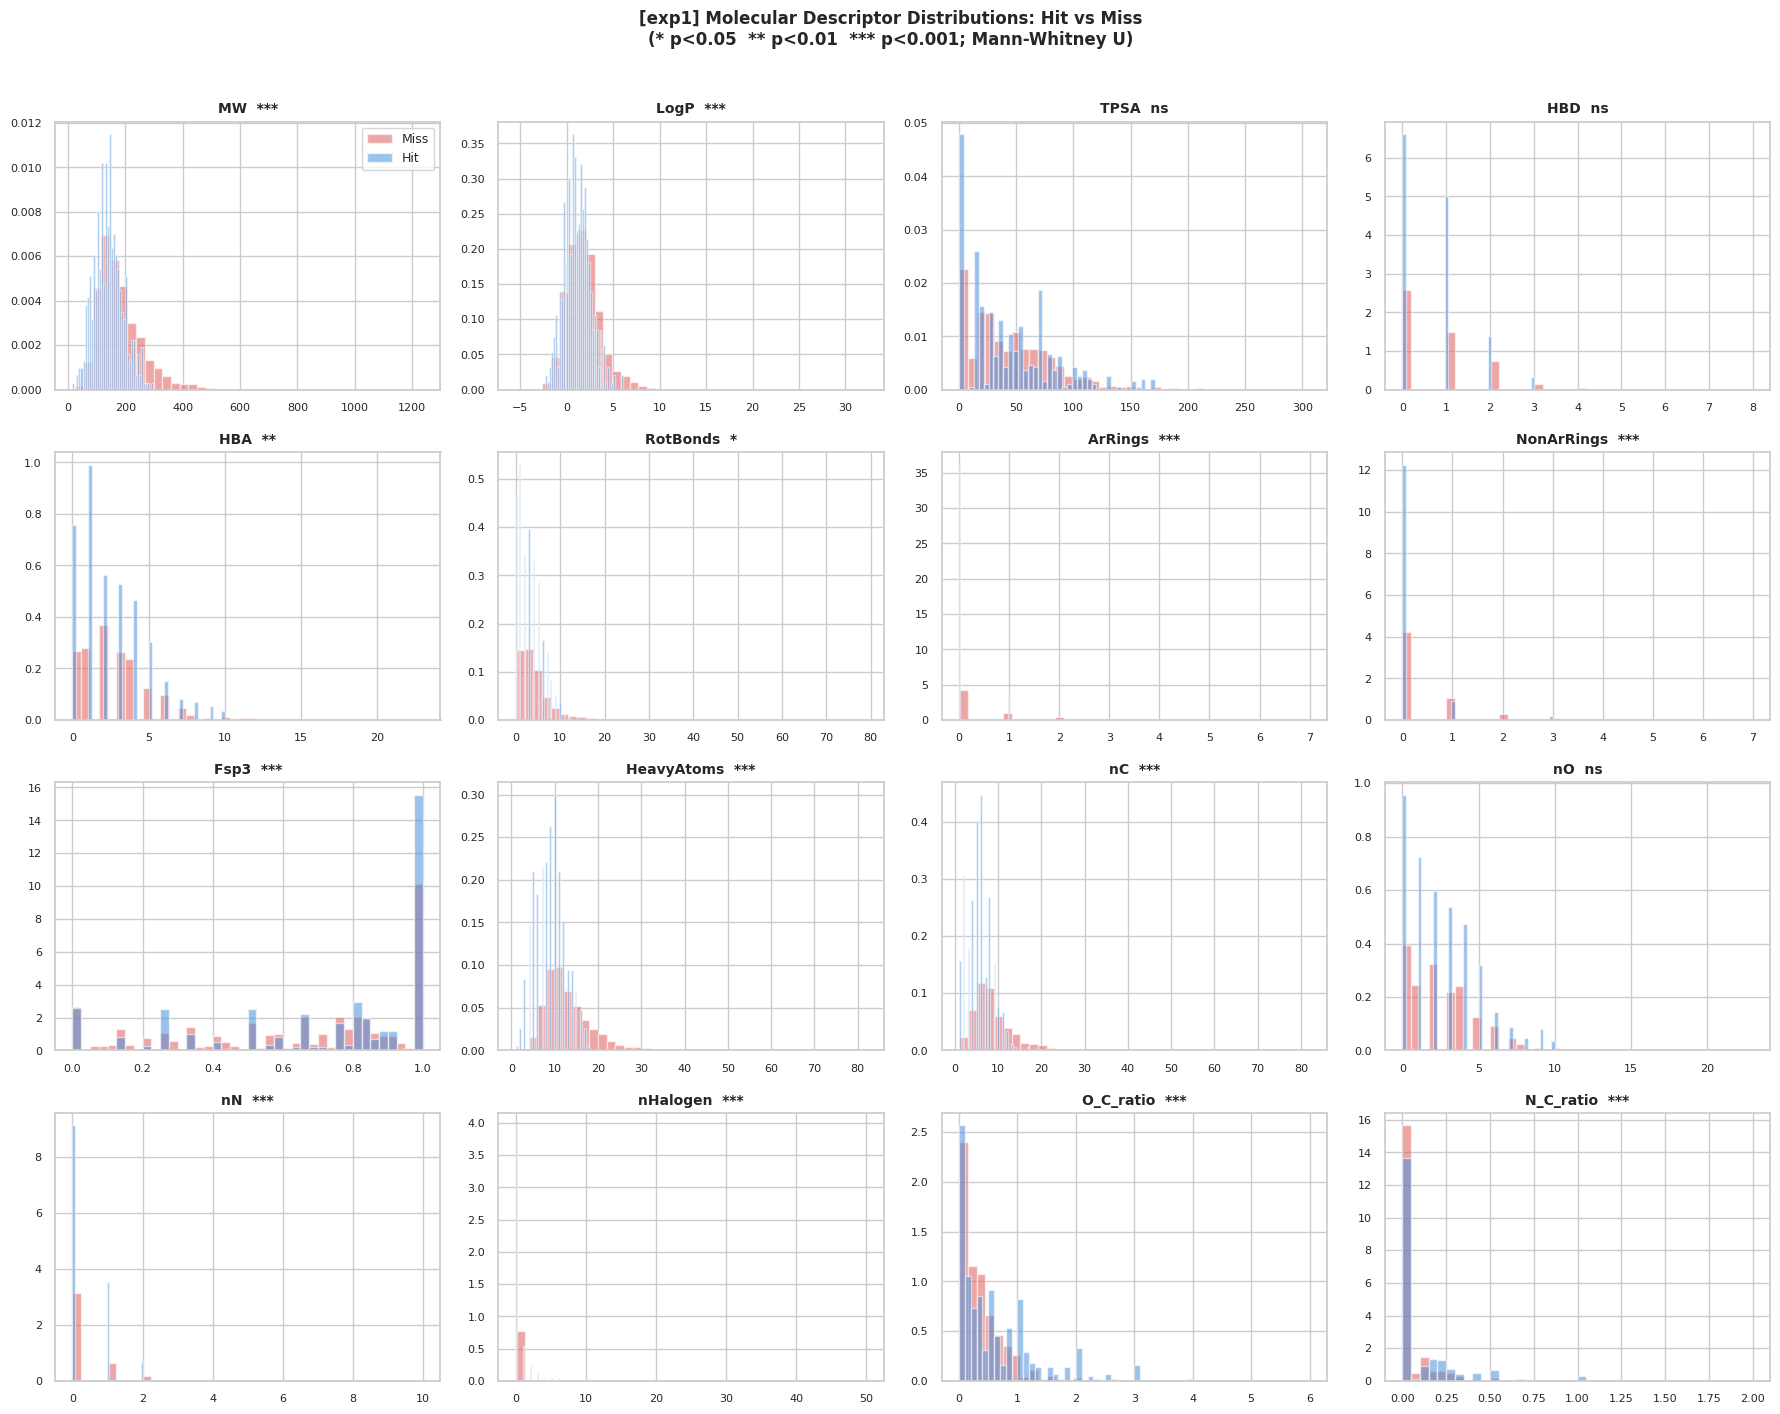

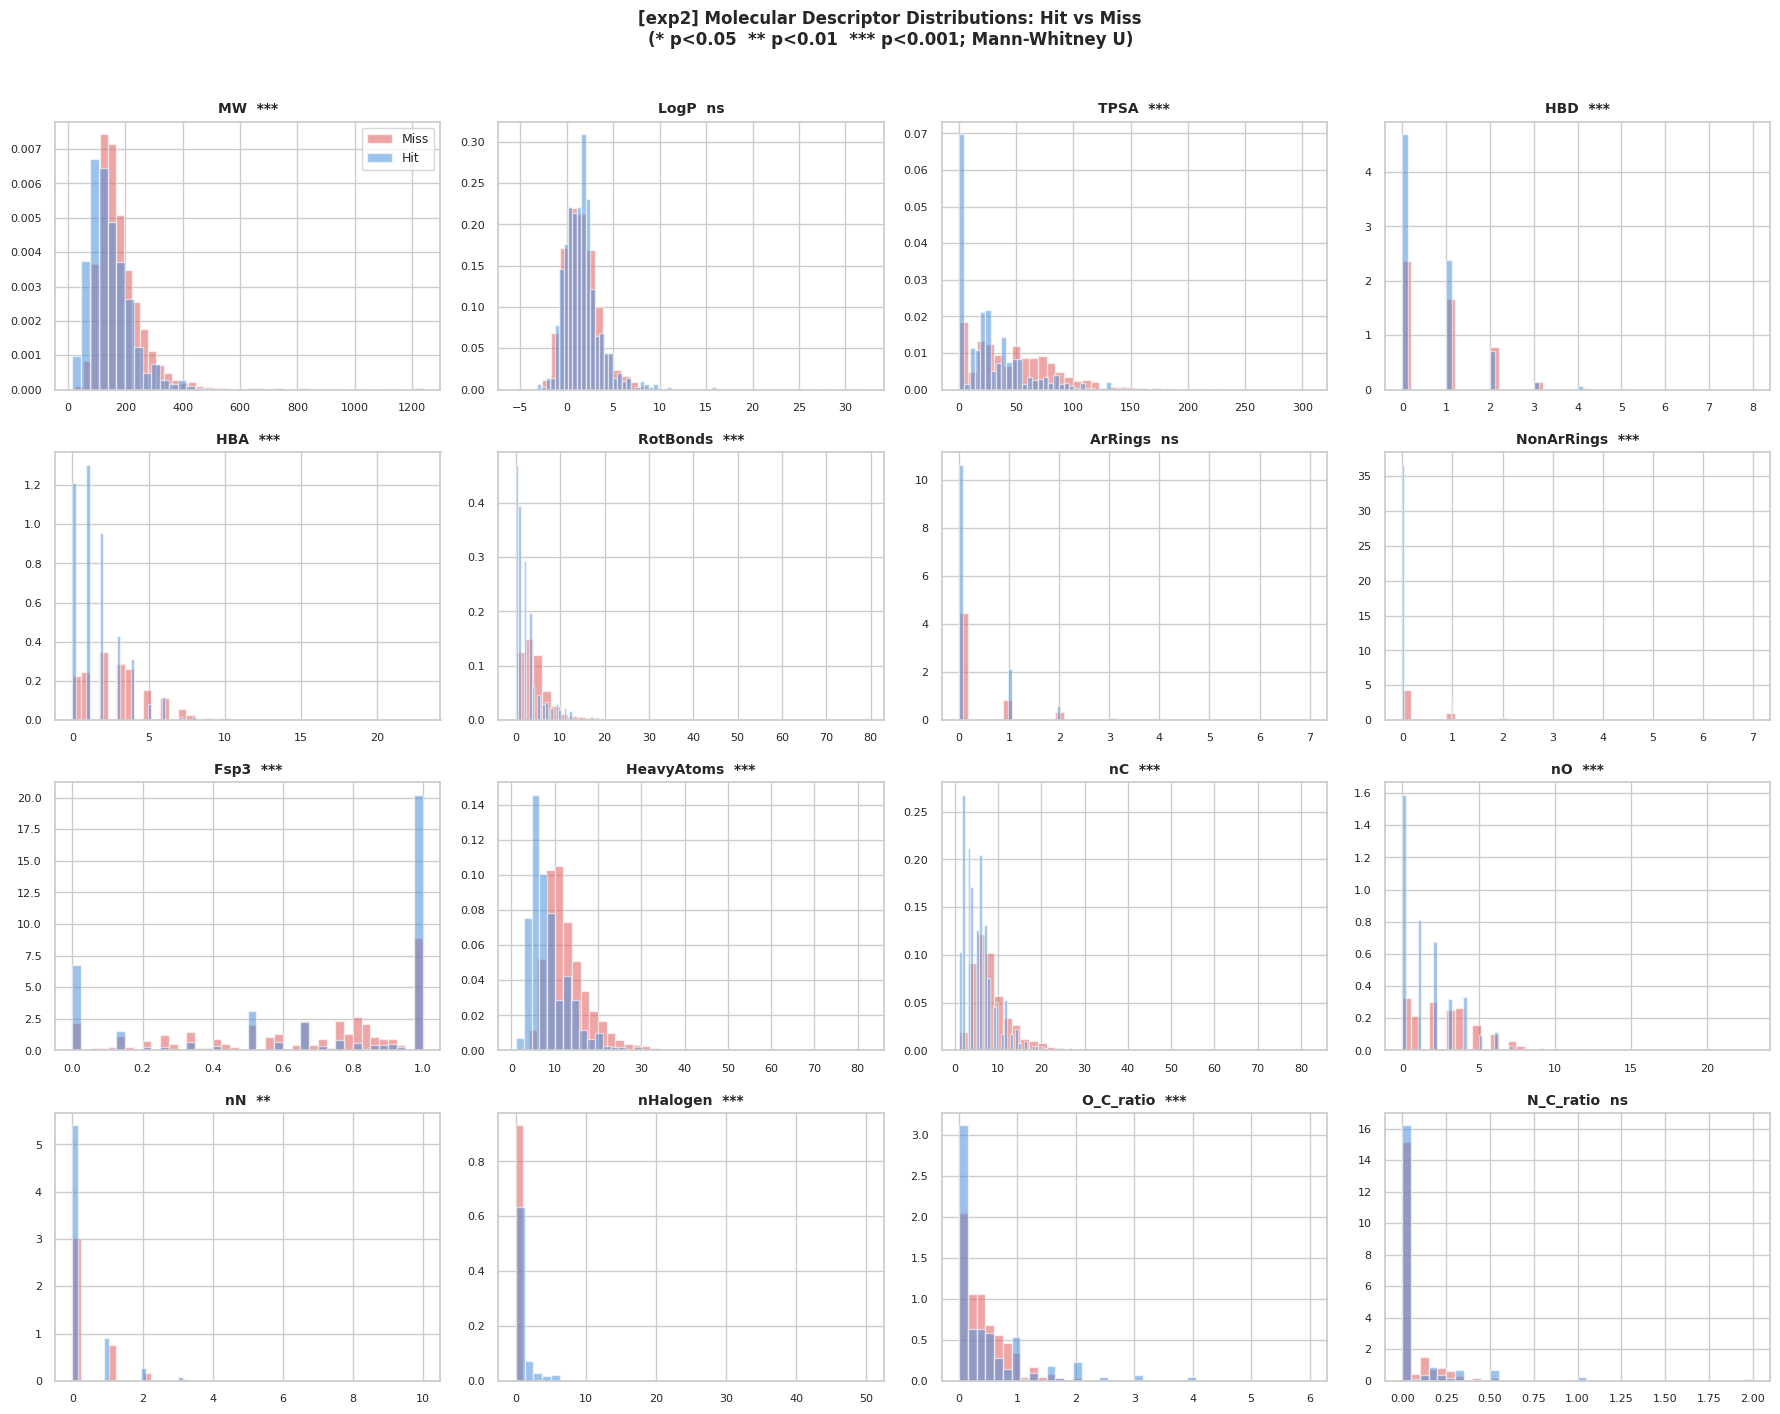

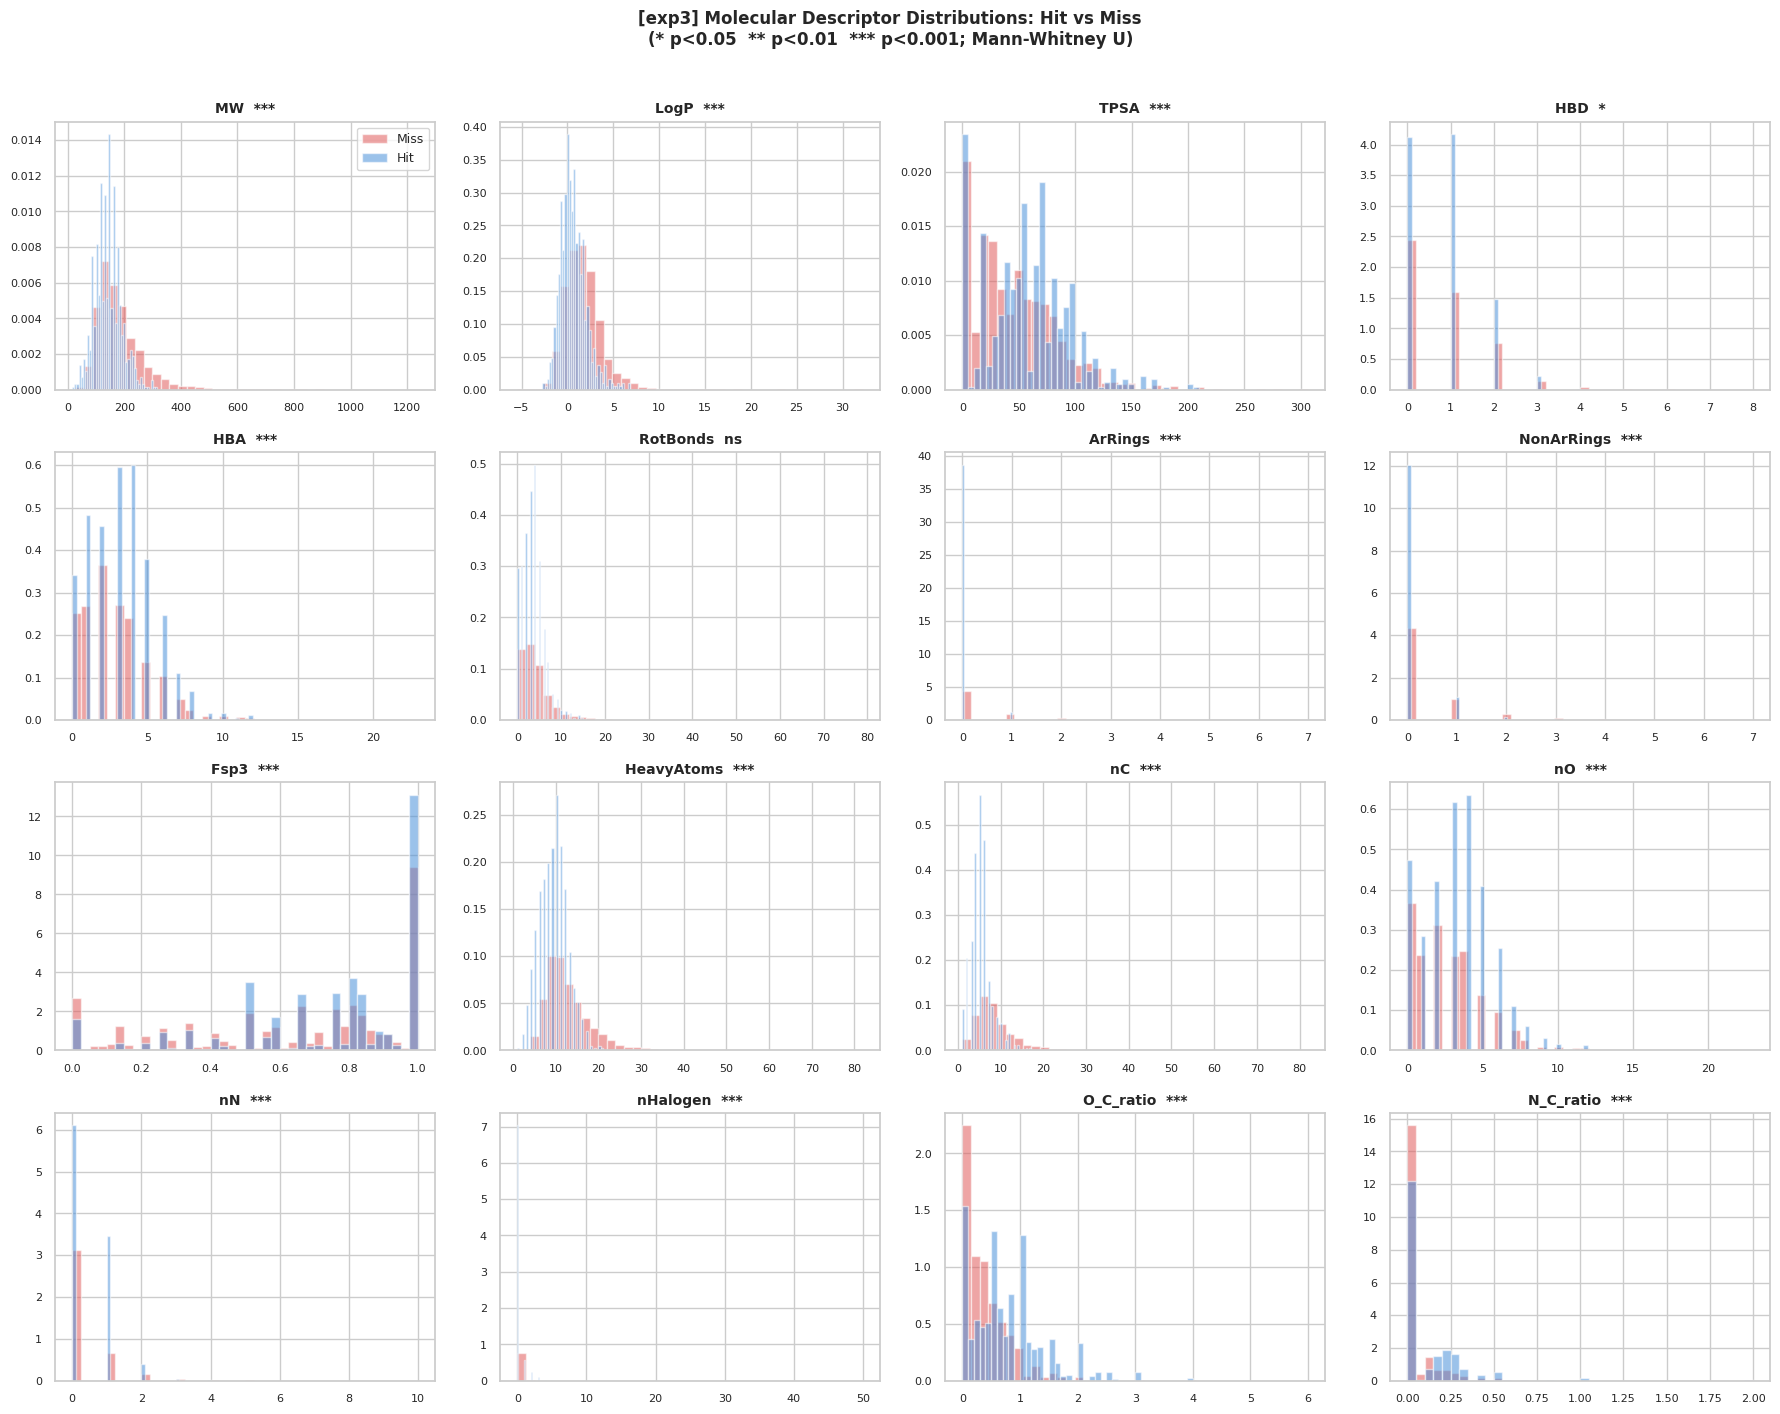

In [20]:
desc_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds',
             'ArRings', 'NonArRings', 'Fsp3', 'HeavyAtoms',
             'nC', 'nO', 'nN', 'nHalogen', 'O_C_ratio', 'N_C_ratio']

for exp_name, adf in exp_dfs.items():
    hit  = adf[adf['hit_top10']]
    miss = adf[~adf['hit_top10']]

    fig, axes = plt.subplots(4, 4, figsize=(18, 14))
    axes = axes.flatten()
    for ax, col in zip(axes, desc_cols):
        h_vals = hit[col].dropna()
        m_vals = miss[col].dropna()
        ax.hist(m_vals, bins=40, alpha=0.55, color='#e05c5c', label='Miss', density=True)
        ax.hist(h_vals, bins=40, alpha=0.55, color='#4a90d9', label='Hit',  density=True)
        stat, pval = stats.mannwhitneyu(h_vals, m_vals, alternative='two-sided')
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        ax.set_title(f'{col}  {sig}', fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=8)
    axes[0].legend(fontsize=9)
    fig.suptitle(f'[{exp_name}] Molecular Descriptor Distributions: Hit vs Miss\n'
                 f'(* p<0.05  ** p<0.01  *** p<0.001; Mann-Whitney U)',
                 y=1.01, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [21]:
for exp_name, adf in exp_dfs.items():
    hit  = adf[adf['hit_top10']]
    miss = adf[~adf['hit_top10']]
    rows = []
    for col in desc_cols:
        h_vals = hit[col].dropna()
        m_vals = miss[col].dropna()
        stat, pval = stats.mannwhitneyu(h_vals, m_vals, alternative='two-sided')
        rows.append({
            'Feature': col,
            'Mean (Hit)': h_vals.mean(),
            'Mean (Miss)': m_vals.mean(),
            'Diff (Hit-Miss)': h_vals.mean() - m_vals.mean(),
            'p-value': f'{pval:.2e}',
        })
    print(f'\n=== {exp_name} ===')
    display(pd.DataFrame(rows).sort_values('p-value').round(3))


=== exp1 ===


,Feature,Mean (Hit),Mean (Miss),Diff (Hit-Miss),p-value
12,nN,0.373,0.308,0.064,1.03e-05
0,MW,138.534,186.051,-47.517,1.10e-32
5,RotBonds,3.134,4.055,-0.921,1.11e-02
10,nC,5.471,9.273,-3.802,1.51e-71
4,HBA,2.489,2.754,-0.265,1.86e-03
11,nO,2.487,2.601,-0.115,2.19e-01
9,HeavyAtoms,8.795,12.653,-3.859,3.29e-47
8,Fsp3,0.727,0.654,0.073,3.38e-08
2,TPSA,43.901,44.321,-0.420,3.51e-01
6,ArRings,0.096,0.372,-0.276,3.62e-15



=== exp2 ===


,Feature,Mean (Hit),Mean (Miss),Diff (Hit-Miss),p-value
0,MW,150.122,181.426,-31.304,1.24e-34
8,Fsp3,0.683,0.654,0.029,1.47e-09
6,ArRings,0.249,0.324,-0.074,1.67e-01
3,HBD,0.566,0.776,-0.211,1.97e-09
11,nO,1.525,2.878,-1.353,2.92e-51
14,O_C_ratio,0.464,0.427,0.037,4.00e-08
13,nHalogen,1.318,0.136,1.182,4.36e-236
12,nN,0.266,0.325,-0.060,5.37e-03
10,nC,5.443,8.908,-3.465,6.05e-90
15,N_C_ratio,0.075,0.052,0.023,6.28e-02



=== exp3 ===


,Feature,Mean (Hit),Mean (Miss),Diff (Hit-Miss),p-value
9,HeavyAtoms,9.191,12.475,-3.284,1.15e-55
10,nC,5.224,9.021,-3.797,1.22e-143
3,HBD,0.784,0.757,0.027,1.37e-02
2,TPSA,57.175,46.149,11.027,1.88e-17
14,O_C_ratio,0.751,0.393,0.359,2.70e-68
7,NonArRings,0.113,0.352,-0.240,2.75e-21
6,ArRings,0.032,0.351,-0.319,2.78e-41
11,nO,3.299,2.707,0.592,2.81e-15
8,Fsp3,0.741,0.647,0.094,2.90e-14
15,N_C_ratio,0.106,0.048,0.058,2.98e-34


## 4. ATMoMACC v5 ATMO feature analysis


=== exp1 — ATMO features that HURT accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
10,ether,397,0.000,0.071,-0.071,0.000
23,"ether, aromatic",197,0.000,0.069,-0.069,0.000
11,peroxide,192,0.000,0.069,-0.069,0.000
2,"amine, tertiary",71,0.000,0.068,-0.068,0.023
28,nC-OHside-a,39,0.000,0.067,-0.067,0.093
15,amide,37,0.000,0.067,-0.067,0.102
21,"amide, tertiary",32,0.000,0.067,-0.067,0.129
17,organosulfate,16,0.000,0.067,-0.067,0.283
9,"ester, all",981,0.010,0.077,-0.067,0.000
30,non-aromatic ring,1635,0.022,0.082,-0.060,0.000



=== exp1 — ATMO features that HELP accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
6,carbonyl,1605,0.090,0.060,0.031,0.000
31,nitrophenol,48,0.104,0.067,0.037,0.302
18,carbonylperoxynitrate,185,0.168,0.064,0.103,0.000
0,"amine, primary",64,0.188,0.066,0.122,0.000
16,nitrate,479,0.186,0.058,0.128,0.000


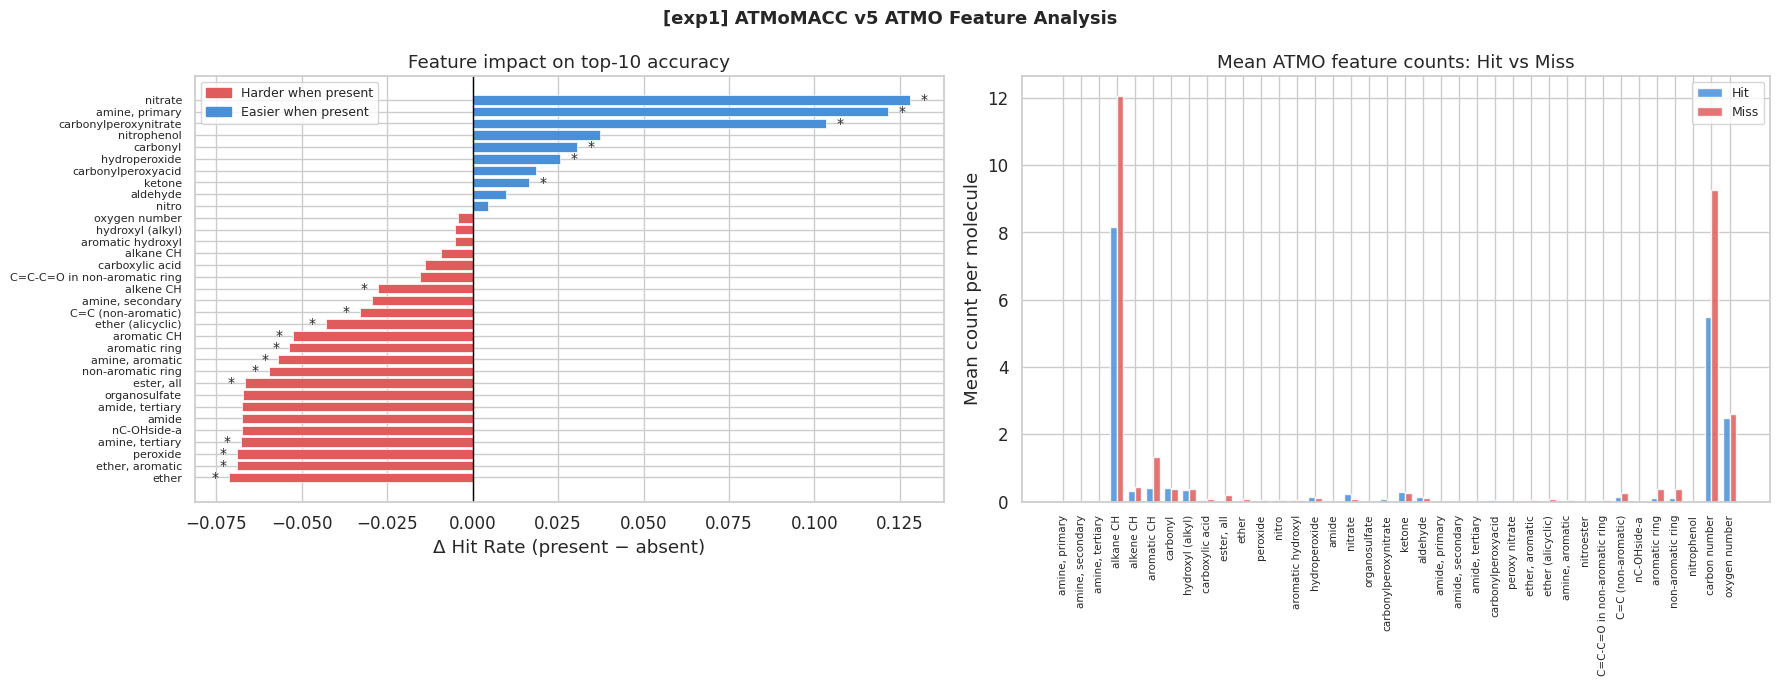


=== exp2 — ATMO features that HURT accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
3,alkane CH,6994,0.068,0.240,-0.172,0.000
33,oxygen number,6013,0.061,0.158,-0.096,0.000
19,ketone,1699,0.009,0.102,-0.093,0.000
6,carbonyl,2199,0.015,0.108,-0.093,0.000
11,peroxide,197,0.000,0.083,-0.083,0.000
26,C=C-C=O in non-aromatic ring,141,0.007,0.082,-0.075,0.001
14,hydroperoxide,927,0.016,0.090,-0.074,0.000
18,carbonylperoxynitrate,278,0.011,0.083,-0.073,0.000
20,aldehyde,991,0.018,0.090,-0.072,0.000
16,nitrate,684,0.018,0.087,-0.070,0.000



=== exp2 — ATMO features that HELP accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
15,amide,37,0.108,0.081,0.027,0.542
1,"amine, secondary",55,0.145,0.080,0.065,0.078
2,"amine, tertiary",72,0.153,0.080,0.073,0.024
0,"amine, primary",68,0.250,0.079,0.171,0.000
17,organosulfate,16,0.312,0.080,0.232,0.001


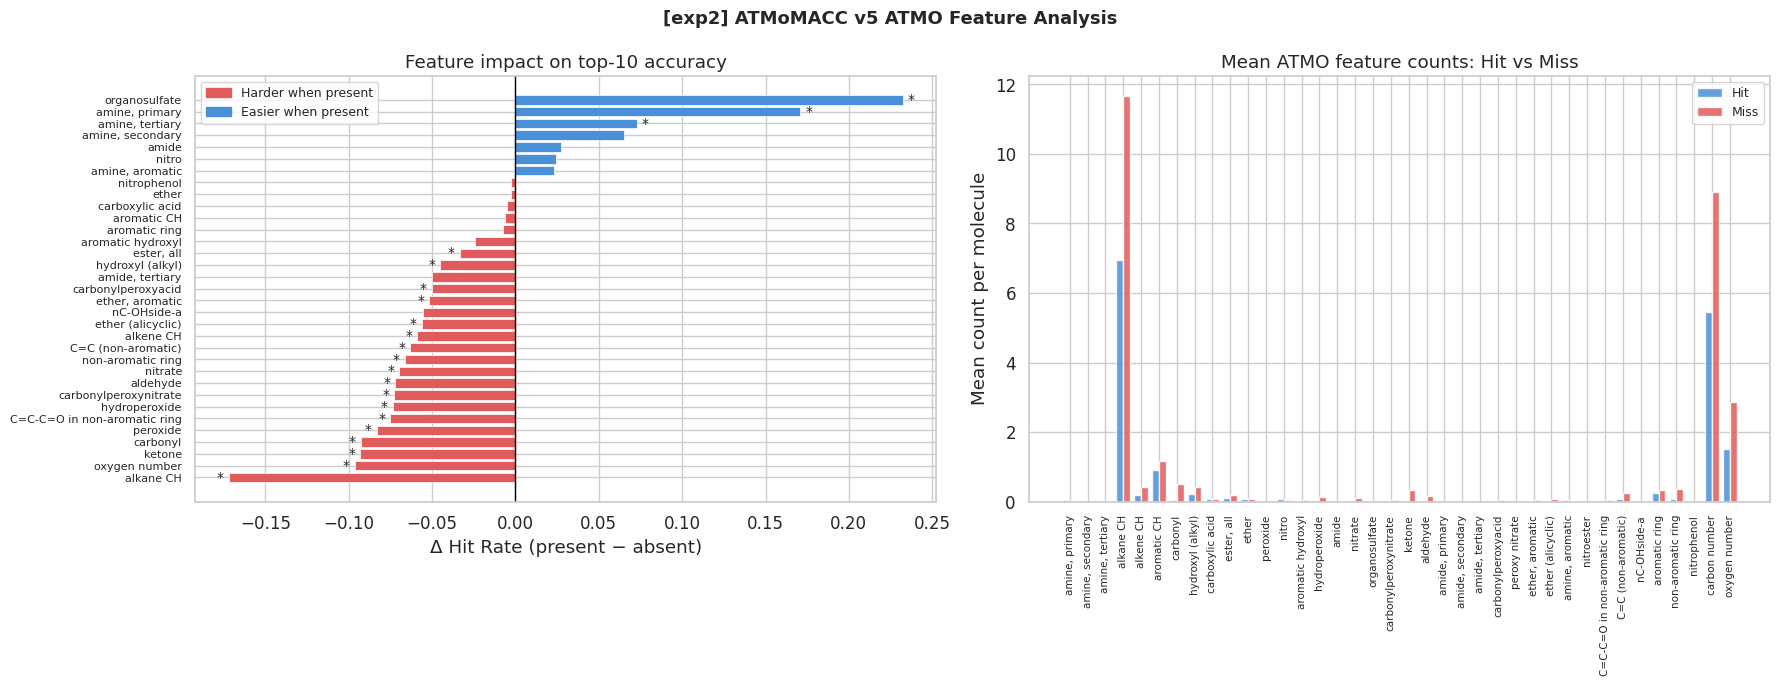


=== exp3 — ATMO features that HURT accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
29,aromatic ring,1657,0.015,0.129,-0.113,0.000
5,aromatic CH,1624,0.015,0.128,-0.112,0.000
10,ether,397,0.003,0.109,-0.107,0.000
23,"ether, aromatic",197,0.000,0.106,-0.106,0.000
2,"amine, tertiary",72,0.000,0.105,-0.105,0.004
28,nC-OHside-a,39,0.000,0.104,-0.104,0.033
15,amide,37,0.000,0.104,-0.104,0.038
21,"amide, tertiary",32,0.000,0.104,-0.104,0.054
17,organosulfate,16,0.000,0.104,-0.104,0.173
25,"amine, aromatic",174,0.006,0.106,-0.100,0.000



=== exp3 — ATMO features that HELP accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
31,nitrophenol,51,0.176,0.103,0.073,0.087
20,aldehyde,991,0.168,0.094,0.074,0.000
6,carbonyl,2199,0.164,0.079,0.085,0.000
18,carbonylperoxynitrate,278,0.230,0.099,0.131,0.000
16,nitrate,684,0.314,0.083,0.232,0.000


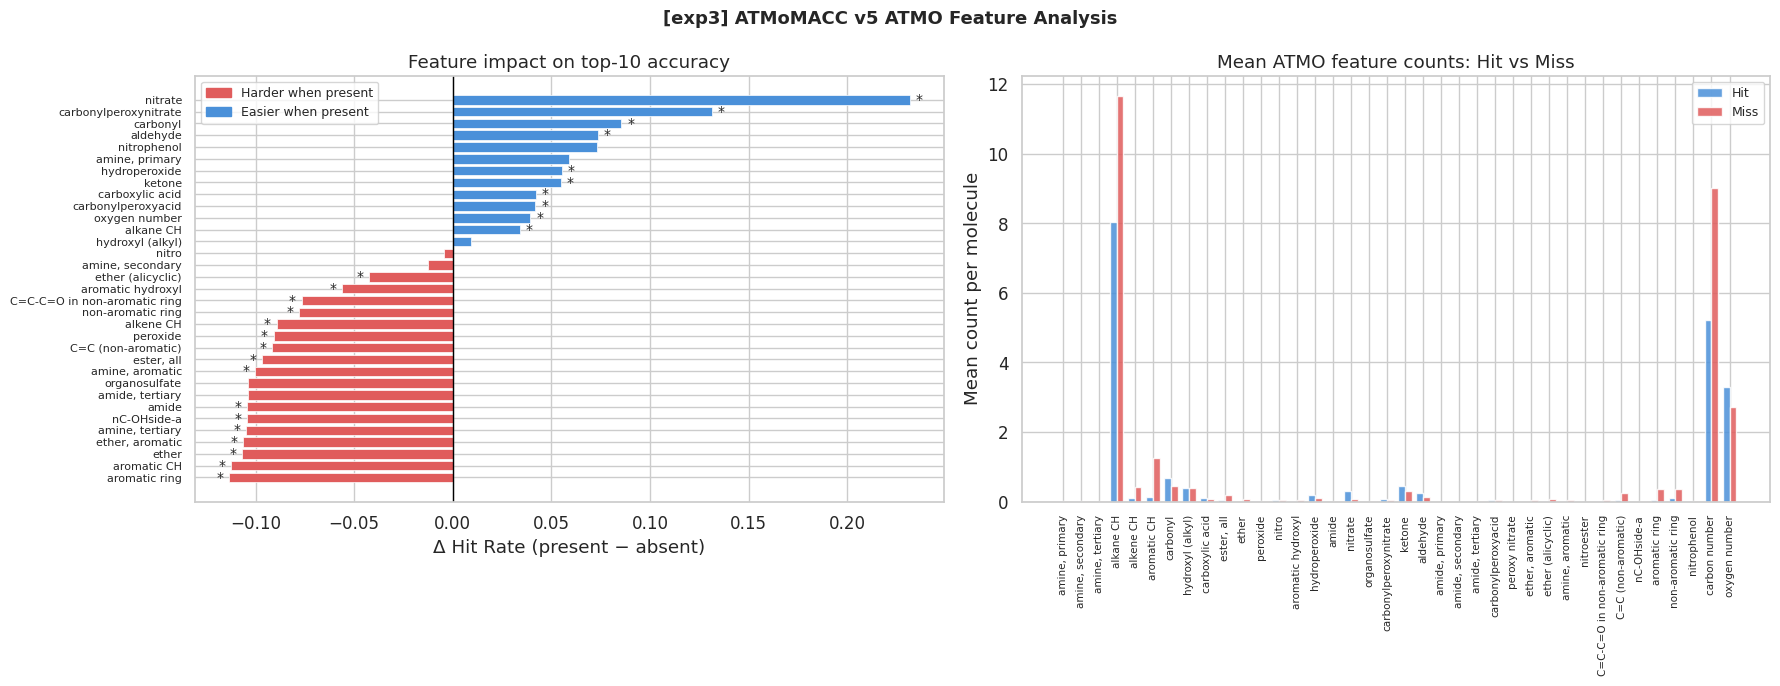

In [22]:
for exp_name, adf in exp_dfs.items():
    hit  = adf[adf['hit_top10']]
    miss = adf[~adf['hit_top10']]

    atmo_rows = []
    for feat in atmo_feat_names:
        has_feat   = adf[adf[feat] > 0]
        lacks_feat = adf[adf[feat] == 0]
        if len(has_feat) < 10:
            continue
        hr_has   = has_feat['hit_top10'].mean()
        hr_lacks = lacks_feat['hit_top10'].mean() if len(lacks_feat) > 0 else np.nan
        if len(lacks_feat) >= 5:
            _, pval = stats.mannwhitneyu(
                has_feat['hit_top10'].astype(float),
                lacks_feat['hit_top10'].astype(float),
                alternative='two-sided'
            )
        else:
            pval = np.nan
        atmo_rows.append({
            'Feature': feat,
            'n (has)': len(has_feat),
            'Hit rate (has)': hr_has,
            'Hit rate (lacks)': hr_lacks,
            'Delta (has-lacks)': hr_has - hr_lacks if not np.isnan(hr_lacks) else np.nan,
            'p-value': pval,
        })
    atmo_stats = pd.DataFrame(atmo_rows).sort_values('Delta (has-lacks)')

    print(f'\n=== {exp_name} \u2014 ATMO features that HURT accuracy ===')
    display(atmo_stats[atmo_stats['Delta (has-lacks)'] < 0].head(10).round(3))
    print(f'\n=== {exp_name} \u2014 ATMO features that HELP accuracy ===')
    display(atmo_stats[atmo_stats['Delta (has-lacks)'] > 0].tail(5).round(3))

    # Bar plot: hit-rate delta per feature
    plot_df = atmo_stats.dropna(subset=['Delta (has-lacks)'])
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    colors = ['#e05c5c' if d < 0 else '#4a90d9' for d in plot_df['Delta (has-lacks)']]
    axes[0].barh(plot_df['Feature'], plot_df['Delta (has-lacks)'], color=colors, edgecolor='white', linewidth=0.5)
    axes[0].axvline(0, color='black', linewidth=1)
    for i, (_, row) in enumerate(plot_df.iterrows()):
        if pd.notna(row['p-value']) and row['p-value'] < 0.05:
            x = row['Delta (has-lacks)']
            axes[0].text(x + (0.003 if x >= 0 else -0.003), i, '*',
                         va='center', ha='left' if x >= 0 else 'right', fontsize=10)
    axes[0].set_xlabel('\u0394 Hit Rate (present \u2212 absent)')
    axes[0].set_title('Feature impact on top-10 accuracy')
    axes[0].tick_params(axis='y', labelsize=8)
    red_p  = mpatches.Patch(color='#e05c5c', label='Harder when present')
    blue_p = mpatches.Patch(color='#4a90d9', label='Easier when present')
    axes[0].legend(handles=[red_p, blue_p], fontsize=9)

    # Mean count: hit vs miss
    x = np.arange(len(atmo_feat_names))
    w = 0.38
    axes[1].bar(x - w/2, hit[atmo_feat_names].mean(),  width=w, label='Hit',  color='#4a90d9', alpha=0.85)
    axes[1].bar(x + w/2, miss[atmo_feat_names].mean(), width=w, label='Miss', color='#e05c5c', alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(atmo_feat_names, rotation=90, fontsize=7.5)
    axes[1].set_ylabel('Mean count per molecule')
    axes[1].set_title('Mean ATMO feature counts: Hit vs Miss')
    axes[1].legend(fontsize=9)

    fig.suptitle(f'[{exp_name}] ATMoMACC v5 ATMO Feature Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. PCA of ATMoMACC v5 fingerprint space


=== exp1 — explained variance ratio (PC1-10) ===
[0.11  0.069 0.068 0.047 0.042 0.035 0.03  0.026 0.026 0.023]
Cumulative (PC1-5): 0.336


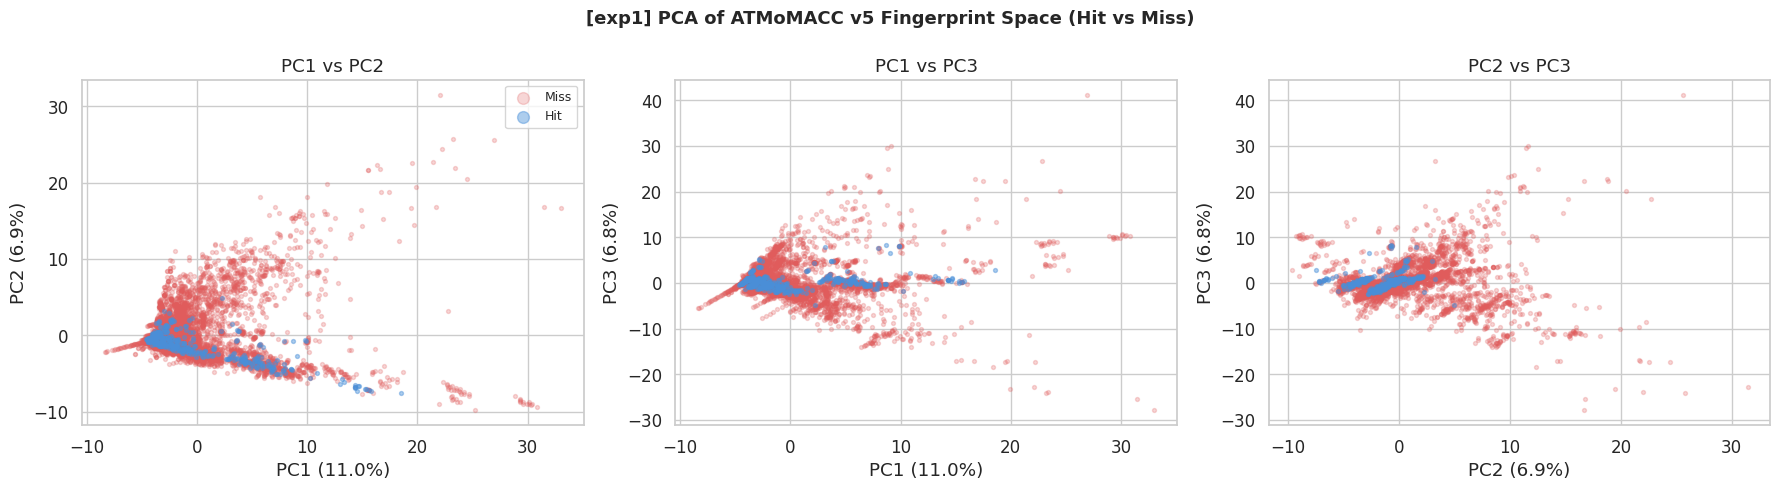

  Top 10 contributors to PC1:
   {'MACCS_63': 0.15899816155433655, 'MACCS_94': 0.15944446623325348, 'MACCS_140': 0.18835535645484924, 'MACCS_146': 0.18835535645484924, 'MACCS_159': 0.18835535645484924, 'MACCS_164': 0.18835535645484924, 'oxygen number': 0.18835535645484924, 'MACCS_102': 0.19337798655033112, 'MACCS_124': 0.19447803497314453, 'MACCS_130': 0.19447803497314453}
  Top 10 contributors to PC2:
   {'MACCS_55': 0.17158642411231995, 'MACCS_58': 0.17664270102977753, 'MACCS_61': 0.18248948454856873, 'MACCS_73': 0.182879239320755, 'MACCS_60': 0.1829388439655304, 'MACCS_67': 0.18566013872623444, 'aromatic CH': 0.18999718129634857, 'MACCS_125': 0.19880101084709167, 'aromatic ring': 0.19880101084709167, 'MACCS_162': 0.20243309438228607}

=== exp2 — explained variance ratio (PC1-10) ===
[0.108 0.07  0.065 0.048 0.043 0.035 0.03  0.026 0.025 0.022]
Cumulative (PC1-5): 0.334


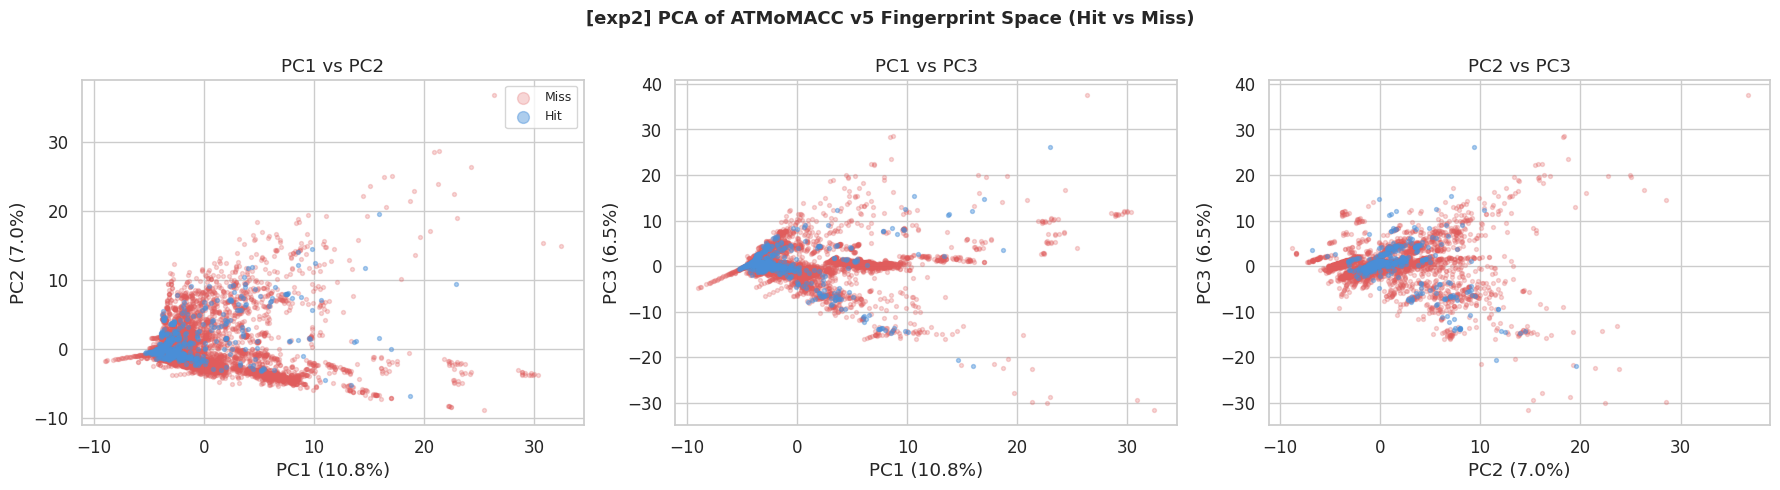

  Top 10 contributors to PC1:
   {'MACCS_63': 0.16824014484882355, 'MACCS_94': 0.16837577521800995, 'oxygen number': 0.1907176524400711, 'MACCS_140': 0.1907176673412323, 'MACCS_146': 0.1907176673412323, 'MACCS_159': 0.1907176673412323, 'MACCS_164': 0.1907176673412323, 'MACCS_102': 0.19770126044750214, 'MACCS_124': 0.1986646056175232, 'MACCS_130': 0.1986646056175232}
  Top 10 contributors to PC2:
   {'MACCS_73': 0.1557016372680664, 'MACCS_60': 0.15581195056438446, 'MACCS_67': 0.1581699550151825, 'MACCS_145': 0.17518600821495056, 'MACCS_163': 0.17518600821495056, 'MACCS_165': 0.18676577508449554, 'aromatic CH': 0.19233764708042145, 'MACCS_125': 0.2057257443666458, 'aromatic ring': 0.2057257443666458, 'MACCS_162': 0.20928509533405304}

=== exp3 — explained variance ratio (PC1-10) ===
[0.108 0.07  0.065 0.048 0.043 0.035 0.03  0.026 0.025 0.022]
Cumulative (PC1-5): 0.334


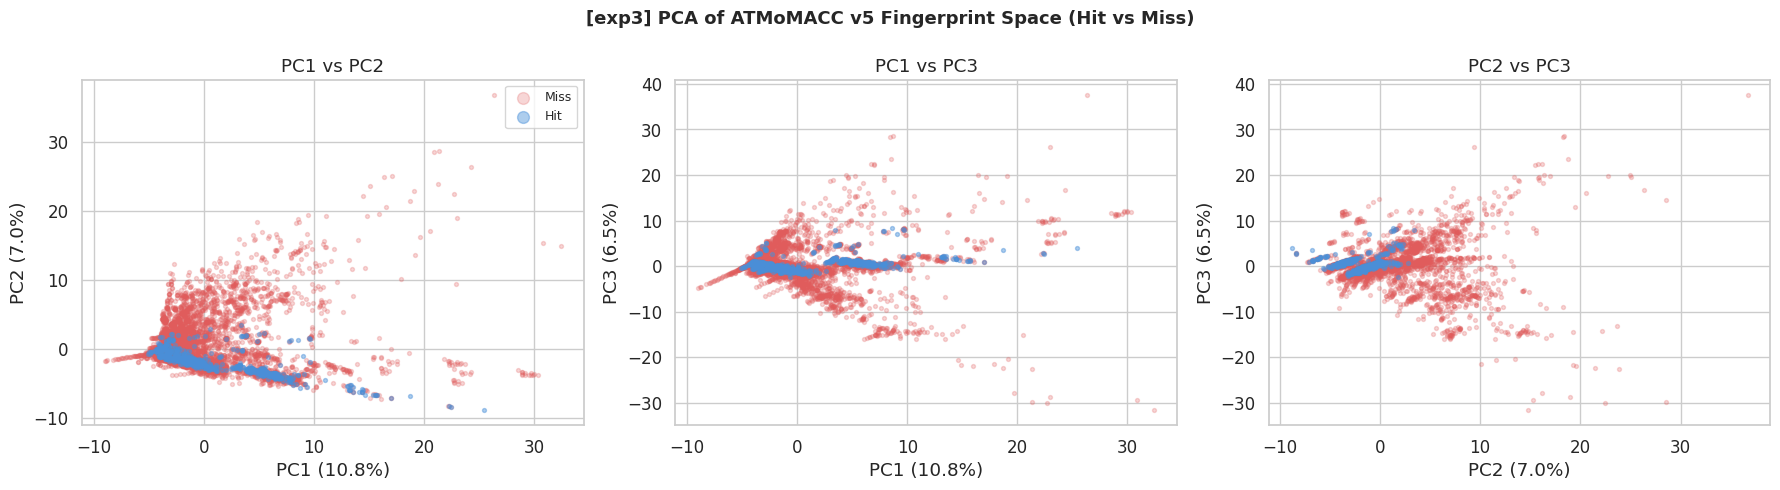

  Top 10 contributors to PC1:
   {'MACCS_63': 0.16824014484882355, 'MACCS_94': 0.16837577521800995, 'oxygen number': 0.1907176524400711, 'MACCS_140': 0.1907176673412323, 'MACCS_146': 0.1907176673412323, 'MACCS_159': 0.1907176673412323, 'MACCS_164': 0.1907176673412323, 'MACCS_102': 0.19770126044750214, 'MACCS_124': 0.1986646056175232, 'MACCS_130': 0.1986646056175232}
  Top 10 contributors to PC2:
   {'MACCS_73': 0.1557016372680664, 'MACCS_60': 0.15581195056438446, 'MACCS_67': 0.1581699550151825, 'MACCS_145': 0.17518600821495056, 'MACCS_163': 0.17518600821495056, 'MACCS_165': 0.18676577508449554, 'aromatic CH': 0.19233764708042145, 'MACCS_125': 0.2057257443666458, 'aromatic ring': 0.2057257443666458, 'MACCS_162': 0.20928509533405304}


In [23]:
exp_pca_results = {}  # {exp_name: {'pcs': arr, 'pca': PCA, 'fp_scaled': arr, 'scaler': scaler}}

for exp_name, adf in exp_dfs.items():
    hit_mask   = adf['hit_top10'].values
    atmomaccs  = exp_fps[exp_name]['atmomaccs']

    scaler    = StandardScaler()
    fp_scaled = scaler.fit_transform(atmomaccs)
    pca       = PCA(n_components=10, random_state=42)
    pcs       = pca.fit_transform(fp_scaled)

    exp_pca_results[exp_name] = {'pcs': pcs, 'pca': pca, 'fp_scaled': fp_scaled, 'scaler': scaler}

    print(f'\n=== {exp_name} \u2014 explained variance ratio (PC1-10) ===')
    print(np.round(pca.explained_variance_ratio_, 3))
    print(f'Cumulative (PC1-5): {pca.explained_variance_ratio_[:5].sum():.3f}')

    # PCA scatter: hit vs miss
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (i, j) in zip(axes, [(0,1), (0,2), (1,2)]):
        ax.scatter(pcs[~hit_mask, i], pcs[~hit_mask, j], c='#e05c5c', alpha=0.25, s=8,
                   label='Miss', rasterized=True)
        ax.scatter(pcs[hit_mask,  i], pcs[hit_mask,  j], c='#4a90d9', alpha=0.45, s=8,
                   label='Hit',  rasterized=True)
        ax.set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
        ax.set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)')
        ax.set_title(f'PC{i+1} vs PC{j+1}')
    axes[0].legend(markerscale=3, fontsize=9)
    fig.suptitle(f'[{exp_name}] PCA of ATMoMACC v5 Fingerprint Space (Hit vs Miss)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # PCA loadings
    loadings = pd.DataFrame(
        pca.components_[:5].T,
        index=atmomaccs_feat_names,
        columns=[f'PC{i+1}' for i in range(5)]
    )
    for pc in ['PC1', 'PC2']:
        top = loadings[pc].abs().nlargest(10).index
        print(f'  Top 10 contributors to {pc}:')
        print('  ', loadings.loc[top, pc].sort_values().to_dict())

## 6. K-means clustering

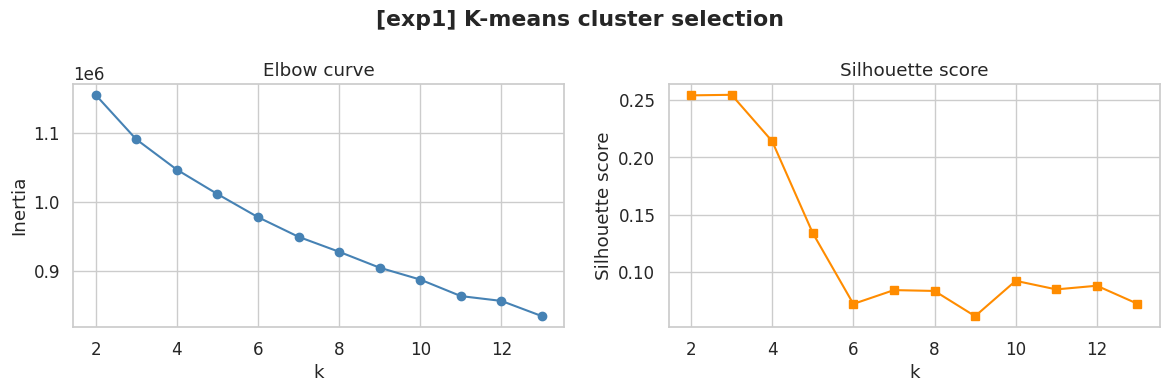

exp1: best k = 3


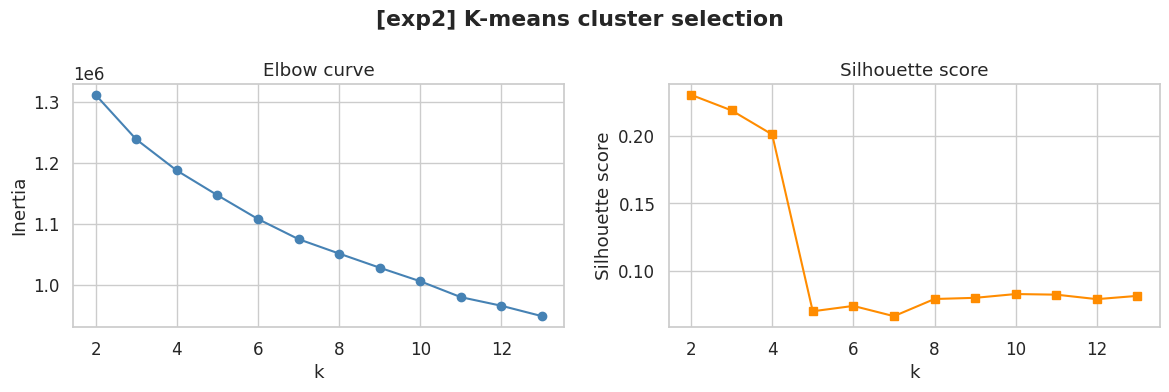

exp2: best k = 2


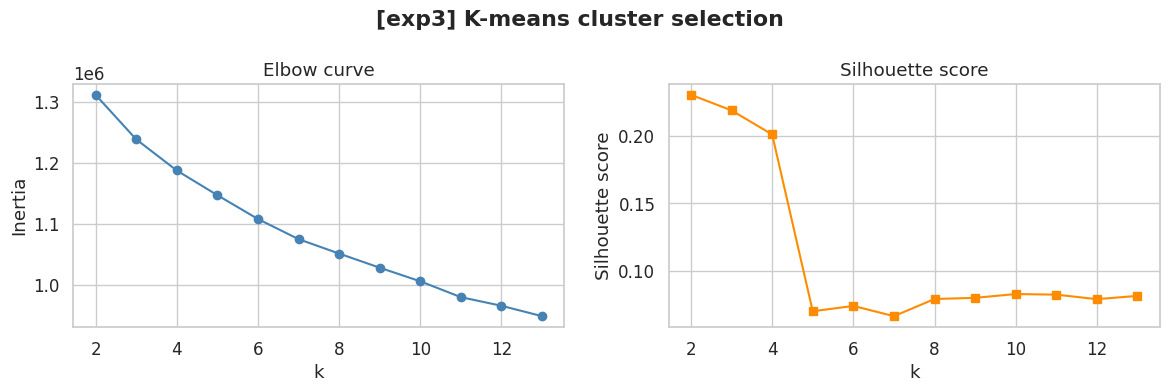

exp3: best k = 2


In [24]:
exp_best_k = {}  # {exp_name: best k from silhouette}

for exp_name in exp_dfs:
    fp_scaled = exp_pca_results[exp_name]['fp_scaled']
    k_range   = range(2, 14)
    inertias, sil_scores = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
        labels = km.fit_predict(fp_scaled)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(fp_scaled, labels,
                                           sample_size=min(5000, len(fp_scaled)), random_state=42))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(list(k_range), inertias,   'o-', color='steelblue')
    ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow curve')
    ax2.plot(list(k_range), sil_scores, 's-', color='darkorange')
    ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette score'); ax2.set_title('Silhouette score')
    fig.suptitle(f'[{exp_name}] K-means cluster selection', fontweight='bold')
    plt.tight_layout()
    plt.show()

    best_k = list(k_range)[np.argmax(sil_scores)]
    exp_best_k[exp_name] = best_k
    print(f'{exp_name}: best k = {best_k}')


=== exp1 (K=3) ===


,n,hit_rate_top1,hit_rate_top5,hit_rate_top10,MW_mean,nC_mean,nO_mean,ArRings_mean,Fsp3_mean
cluster,,,,,,,,,
2,416,0.000,0.002,0.002,285.493,11.995,4.928,1.103,0.487
0,5393,0.020,0.051,0.060,170.023,9.023,1.925,0.314,0.672
1,873,0.042,0.115,0.142,213.294,7.568,5.611,0.245,0.659


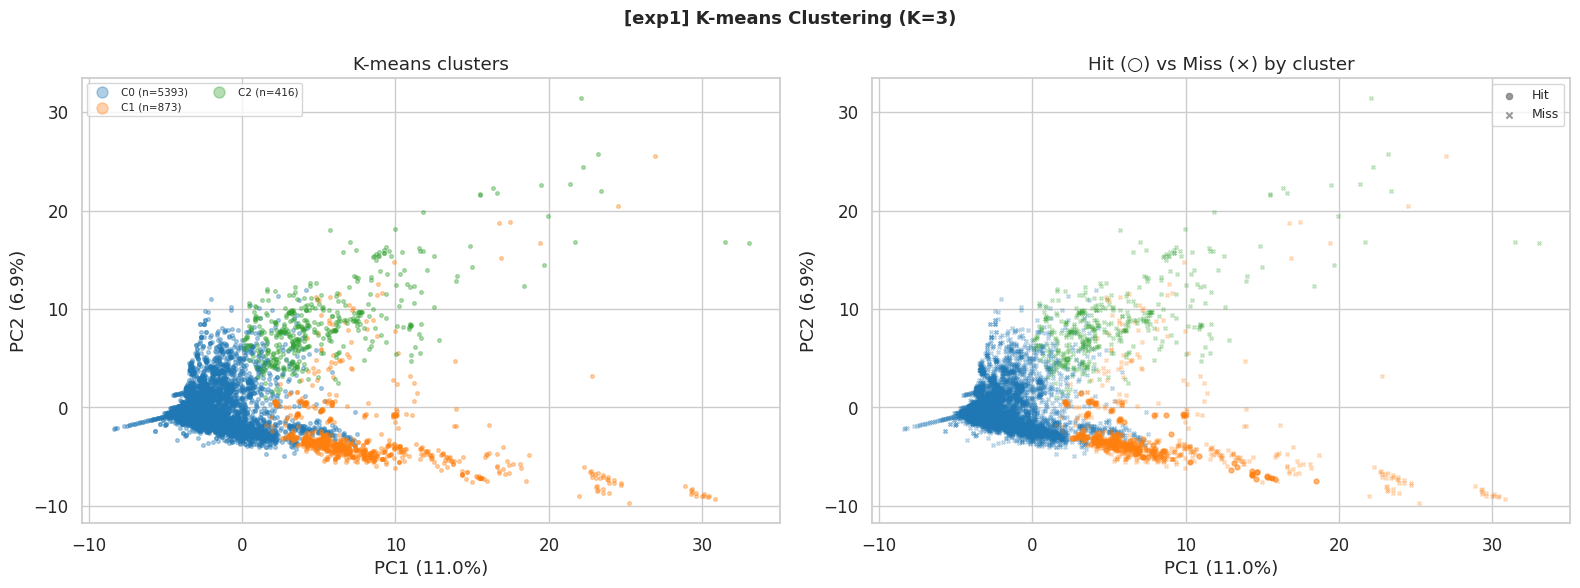

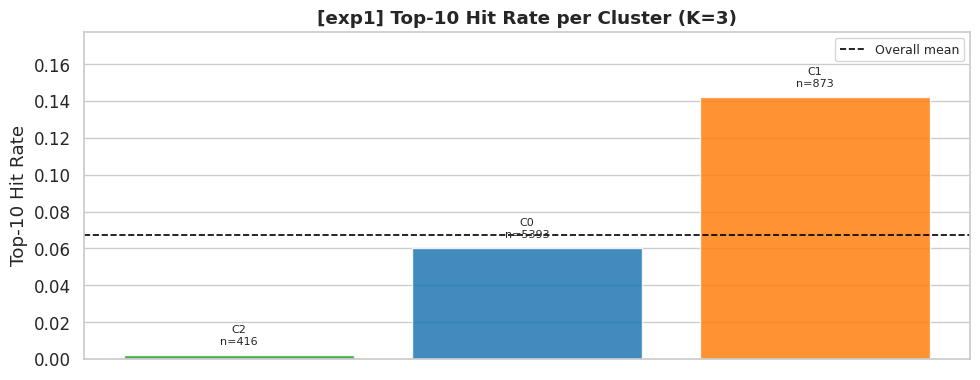

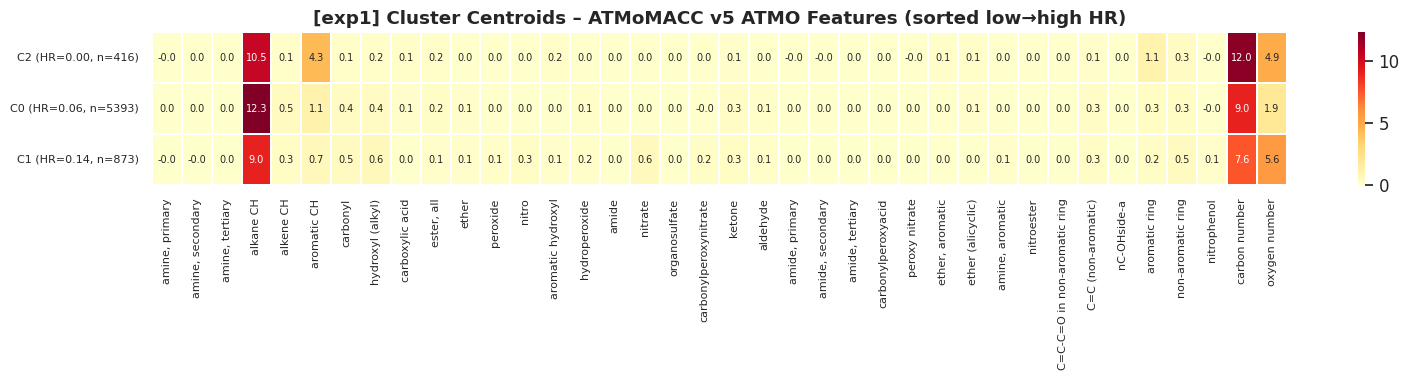


=== exp2 (K=2) ===


,n,hit_rate_top1,hit_rate_top5,hit_rate_top10,MW_mean,nC_mean,nO_mean,ArRings_mean,Fsp3_mean
cluster,,,,,,,,,
1,1480,0.017,0.040,0.052,226.764,8.124,5.703,0.357,0.651
0,6068,0.026,0.064,0.088,167.221,8.750,2.053,0.308,0.658


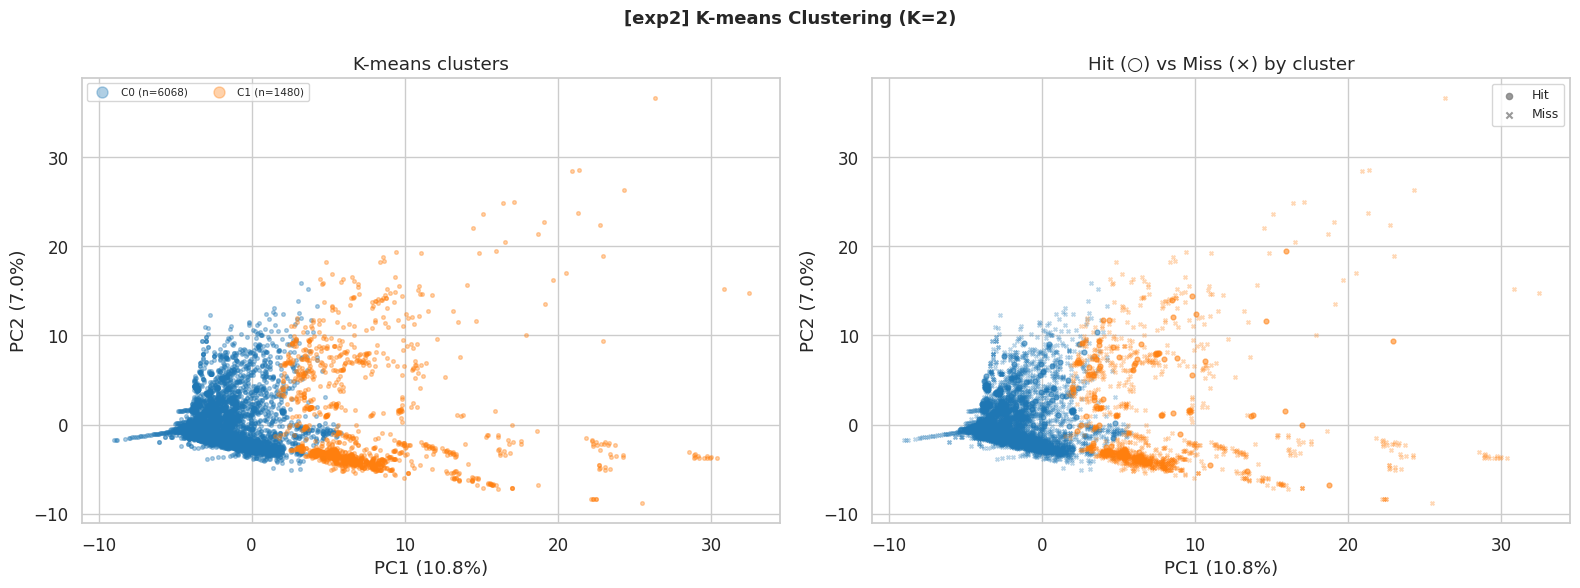

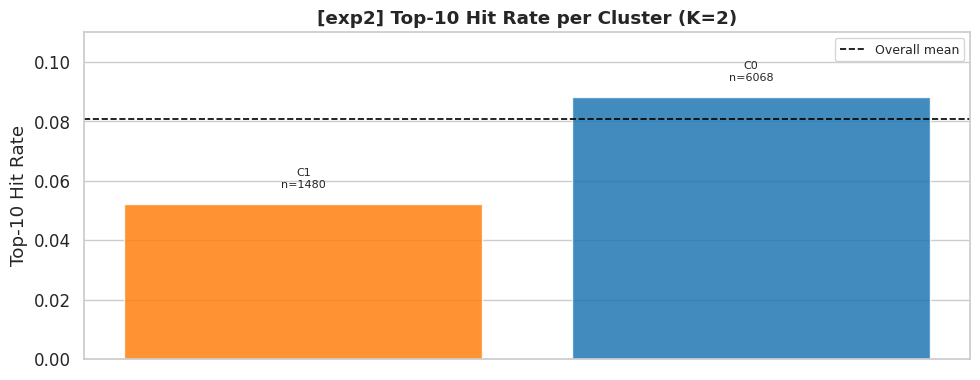

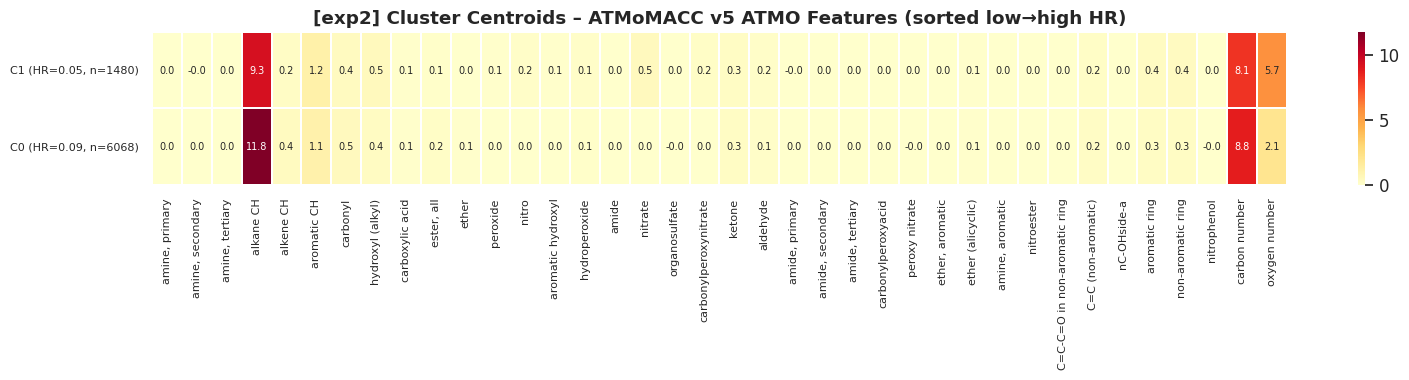


=== exp3 (K=2) ===


,n,hit_rate_top1,hit_rate_top5,hit_rate_top10,MW_mean,nC_mean,nO_mean,ArRings_mean,Fsp3_mean
cluster,,,,,,,,,
0,6068,0.027,0.062,0.082,167.221,8.750,2.053,0.308,0.658
1,1480,0.070,0.158,0.192,226.764,8.124,5.703,0.357,0.651


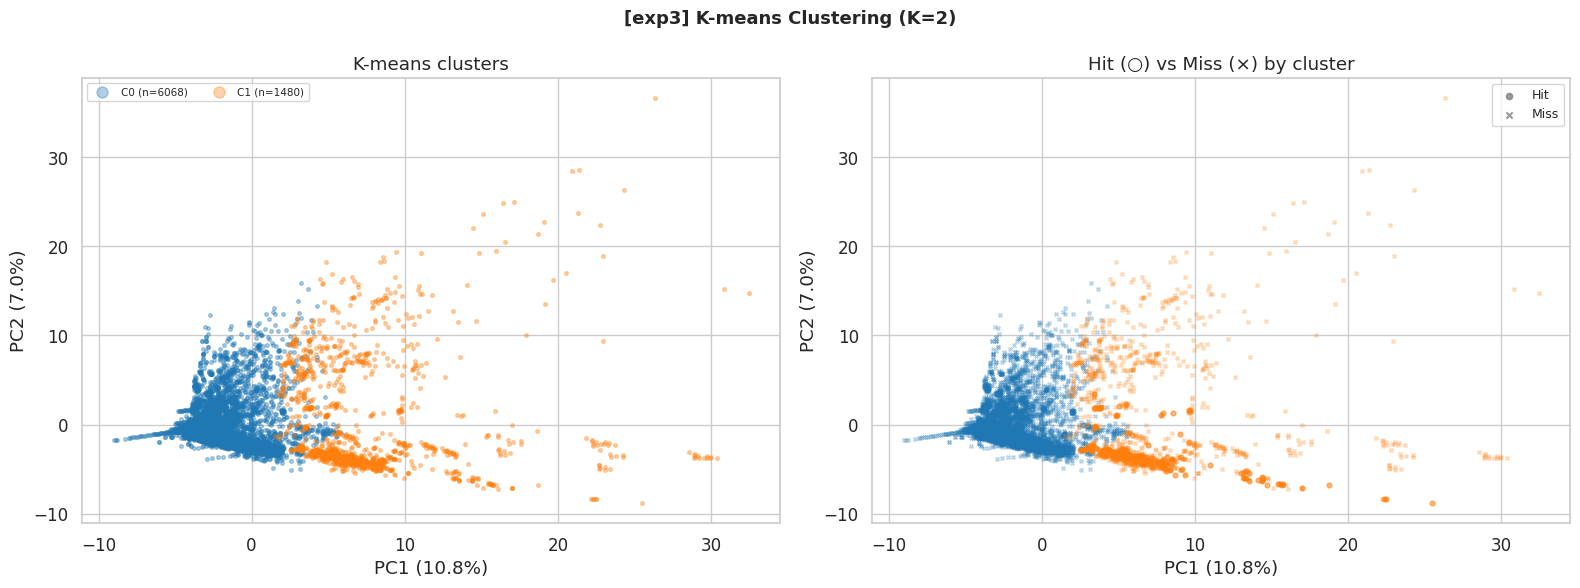

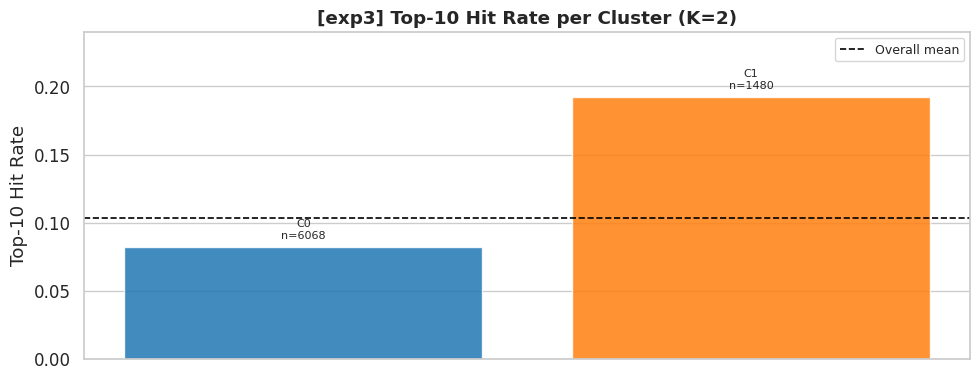

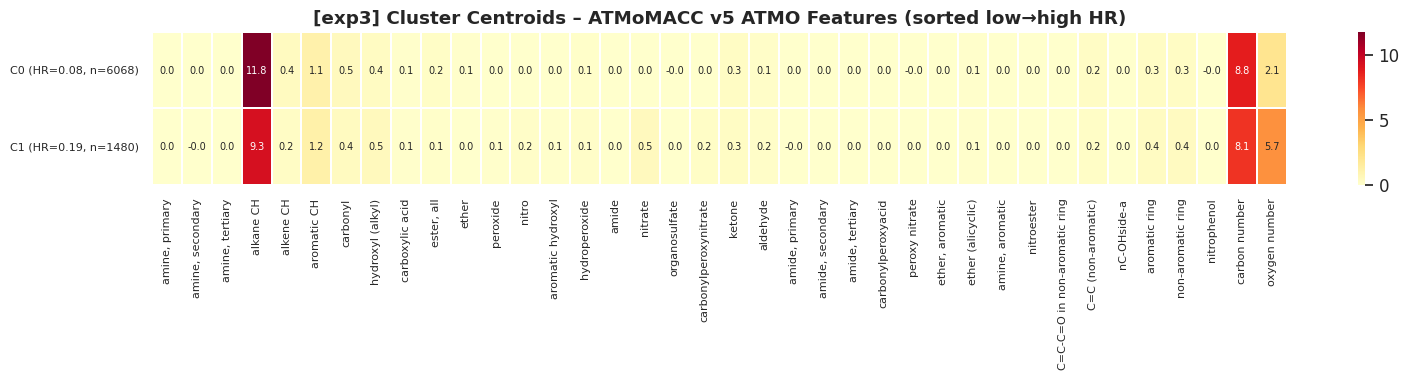

In [25]:
# Override k per experiment here if needed, e.g.: exp_best_k['exp1'] = 6
exp_kmeans_results = {}  # {exp_name: {'cluster_labels', 'cluster_summary', 'palette', 'K', 'km'}}

for exp_name, adf in exp_dfs.items():
    K         = exp_best_k[exp_name]
    fp_scaled = exp_pca_results[exp_name]['fp_scaled']
    pcs       = exp_pca_results[exp_name]['pcs']
    pca       = exp_pca_results[exp_name]['pca']
    scaler    = exp_pca_results[exp_name]['scaler']
    hit_mask  = adf['hit_top10'].values
    palette   = sns.color_palette('tab10', K)

    km_final       = KMeans(n_clusters=K, n_init=20, random_state=42, max_iter=500)
    cluster_labels = km_final.fit_predict(fp_scaled)
    adf = adf.copy()
    adf['cluster'] = cluster_labels
    exp_dfs[exp_name] = adf  # update with cluster column

    cluster_summary = adf.groupby('cluster').agg(
        n=('hit_top10', 'count'),
        hit_rate_top1=('hit_top1', 'mean'),
        hit_rate_top5=('hit_top5', 'mean'),
        hit_rate_top10=('hit_top10', 'mean'),
        MW_mean=('MW', 'mean'),
        nC_mean=('nC', 'mean'),
        nO_mean=('nO', 'mean'),
        ArRings_mean=('ArRings', 'mean'),
        Fsp3_mean=('Fsp3', 'mean'),
    ).round(3)
    exp_kmeans_results[exp_name] = {
        'cluster_labels': cluster_labels, 'cluster_summary': cluster_summary,
        'palette': palette, 'K': K, 'km': km_final,
    }

    print(f'\n=== {exp_name} (K={K}) ===')
    display(cluster_summary.sort_values('hit_rate_top10'))

    # Cluster scatter + hit/miss markers
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax = axes[0]
    for c in range(K):
        m = cluster_labels == c
        ax.scatter(pcs[m, 0], pcs[m, 1], color=palette[c], alpha=0.35, s=7,
                   label=f'C{c} (n={m.sum()})', rasterized=True)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('K-means clusters')
    ax.legend(markerscale=3, fontsize=7.5, ncol=2)

    ax2 = axes[1]
    for c in range(K):
        c_m = cluster_labels == c
        ax2.scatter(pcs[c_m & ~hit_mask, 0], pcs[c_m & ~hit_mask, 1],
                    color=palette[c], alpha=0.3, s=7, marker='x', rasterized=True)
        ax2.scatter(pcs[c_m &  hit_mask, 0], pcs[c_m &  hit_mask, 1],
                    color=palette[c], alpha=0.55, s=12, marker='o', rasterized=True)
    ax2.legend(handles=[
        plt.scatter([], [], marker='o', color='gray', s=20, label='Hit',  alpha=0.8),
        plt.scatter([], [], marker='x', color='gray', s=20, label='Miss', alpha=0.8),
    ], fontsize=9)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax2.set_title('Hit (○) vs Miss (×) by cluster')
    fig.suptitle(f'[{exp_name}] K-means Clustering (K={K})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Hit rate per cluster bar chart
    cs = cluster_summary.sort_values('hit_rate_top10').reset_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(cs.index, cs['hit_rate_top10'],
                  color=[palette[c] for c in cs['cluster']], alpha=0.85, edgecolor='white')
    for bar, (_, row) in zip(bars, cs.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'C{int(row["cluster"])}\nn={int(row["n"])}',
                ha='center', va='bottom', fontsize=8)
    ax.axhline(adf['hit_top10'].mean(), color='black', linestyle='--', linewidth=1.2, label='Overall mean')
    ax.set_ylabel('Top-10 Hit Rate'); ax.set_xticks([])
    ax.set_title(f'[{exp_name}] Top-10 Hit Rate per Cluster (K={K})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, min(1.0, cs['hit_rate_top10'].max() * 1.25))
    plt.tight_layout(); plt.show()

    # Centroid heatmap (ATMO features only)
    centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
    centroid_df    = pd.DataFrame(centroids_orig, columns=atmomaccs_feat_names)
    hr_order       = cluster_summary['hit_rate_top10'].sort_values().index.tolist()
    labels_sorted  = [f'C{c} (HR={cluster_summary.loc[c,"hit_rate_top10"]:.2f}, n={int(cluster_summary.loc[c,"n"])})'
                      for c in hr_order]
    fig, ax = plt.subplots(figsize=(16, max(4, K * 0.6 + 1)))
    sns.heatmap(centroid_df[atmo_feat_names].loc[hr_order], ax=ax,
                yticklabels=labels_sorted, xticklabels=atmo_feat_names,
                cmap='YlOrRd', linewidths=0.3, annot=True, fmt='.1f', annot_kws={'size': 7})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_title(f'[{exp_name}] Cluster Centroids \u2013 ATMoMACC v5 ATMO Features (sorted low\u2192high HR)',
                 fontweight='bold')
    plt.tight_layout(); plt.show()

## 7. Hardest and easiest clusters — representative molecule inspection


=== exp1 ===
Hardest cluster: C2  (hit rate = 0.002)


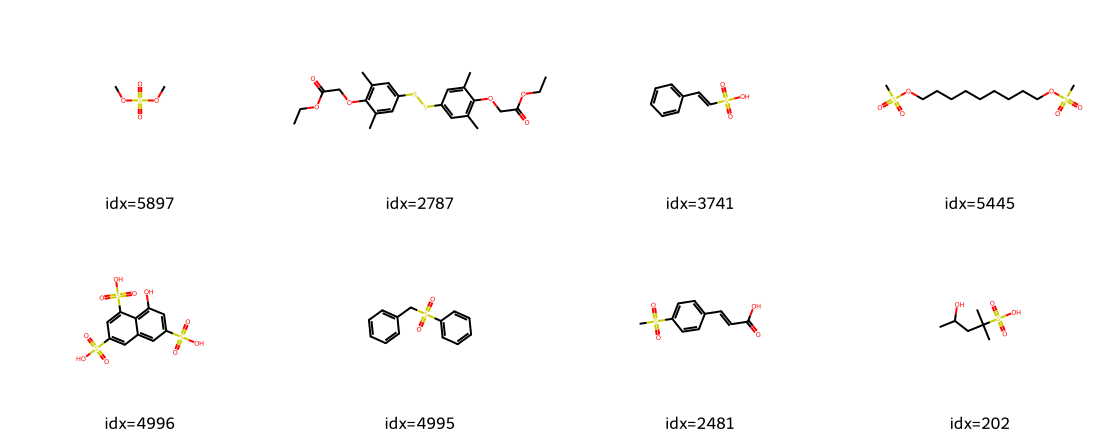

Easiest cluster: C1  (hit rate = 0.142)


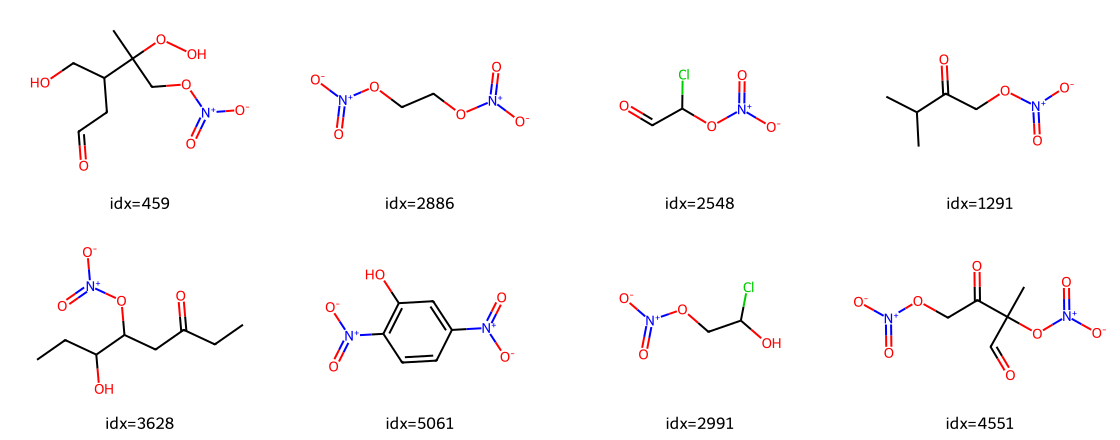


=== exp2 ===
Hardest cluster: C1  (hit rate = 0.052)


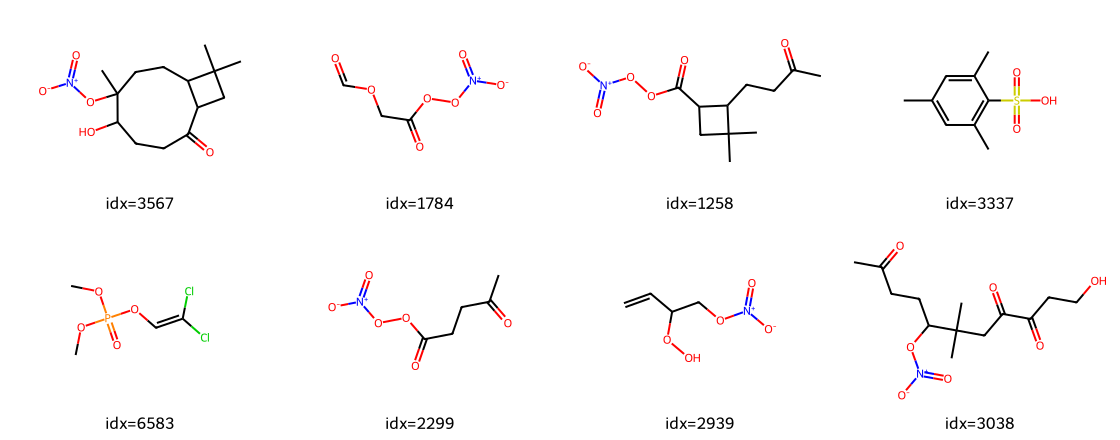

Easiest cluster: C0  (hit rate = 0.088)


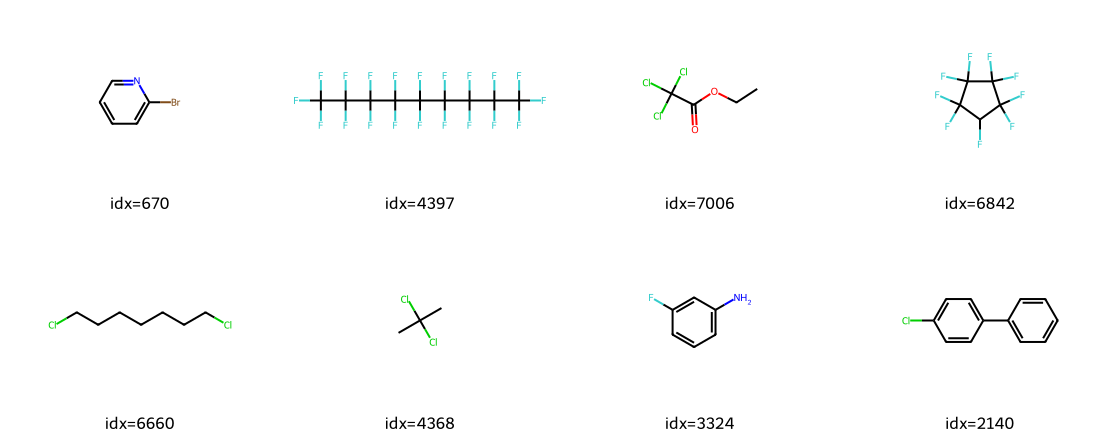


=== exp3 ===
Hardest cluster: C0  (hit rate = 0.082)


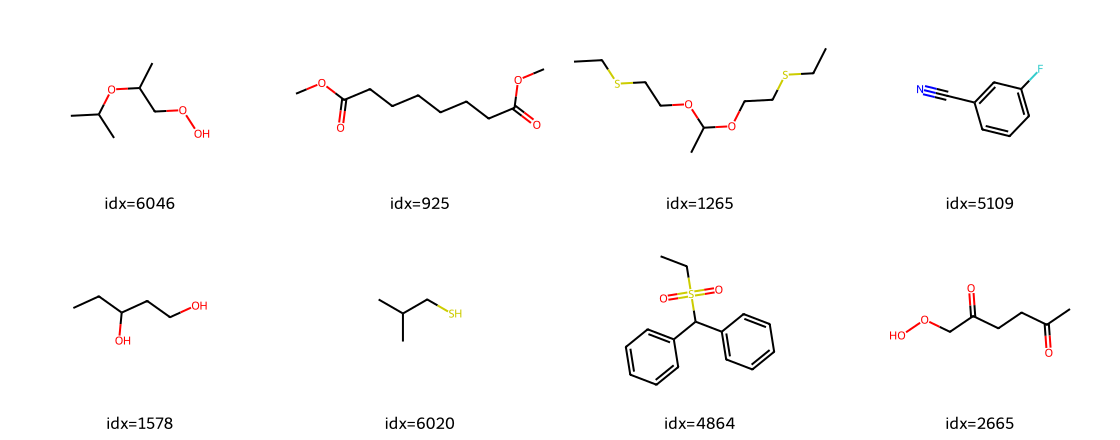

Easiest cluster: C1  (hit rate = 0.192)


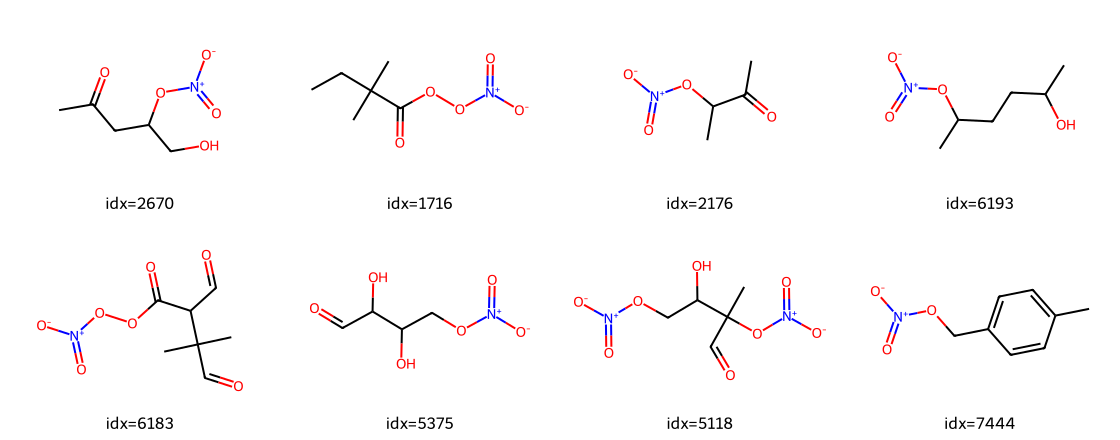

In [26]:
def draw_mols_from_cluster(adf, records, cluster_id, hit_filter, n=8):
    idx = adf.index[(adf['cluster'] == cluster_id) & (adf['hit_top10'] == hit_filter)].tolist()
    np.random.seed(0)
    idx = np.random.choice(idx, min(n, len(idx)), replace=False)
    mols = [records[i]['true_mol'] for i in idx]
    if not mols:
        print('  No molecules found.')
        return None
    return Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(280, 220),
                                legends=[f'idx={i}' for i in idx])

for exp_name, adf in exp_dfs.items():
    km_res  = exp_kmeans_results[exp_name]
    cs      = km_res['cluster_summary']
    records = experiments_records[exp_name]

    hardest = cs['hit_rate_top10'].idxmin()
    easiest = cs['hit_rate_top10'].idxmax()

    print(f'\n=== {exp_name} ===')
    print(f'Hardest cluster: C{hardest}  (hit rate = {cs.loc[hardest,"hit_rate_top10"]:.3f})')
    img = draw_mols_from_cluster(adf, records, hardest, hit_filter=False)
    if img: display(img)

    print(f'Easiest cluster: C{easiest}  (hit rate = {cs.loc[easiest,"hit_rate_top10"]:.3f})')
    img = draw_mols_from_cluster(adf, records, easiest, hit_filter=True)
    if img: display(img)

## 8. Summary: top predictors of difficulty

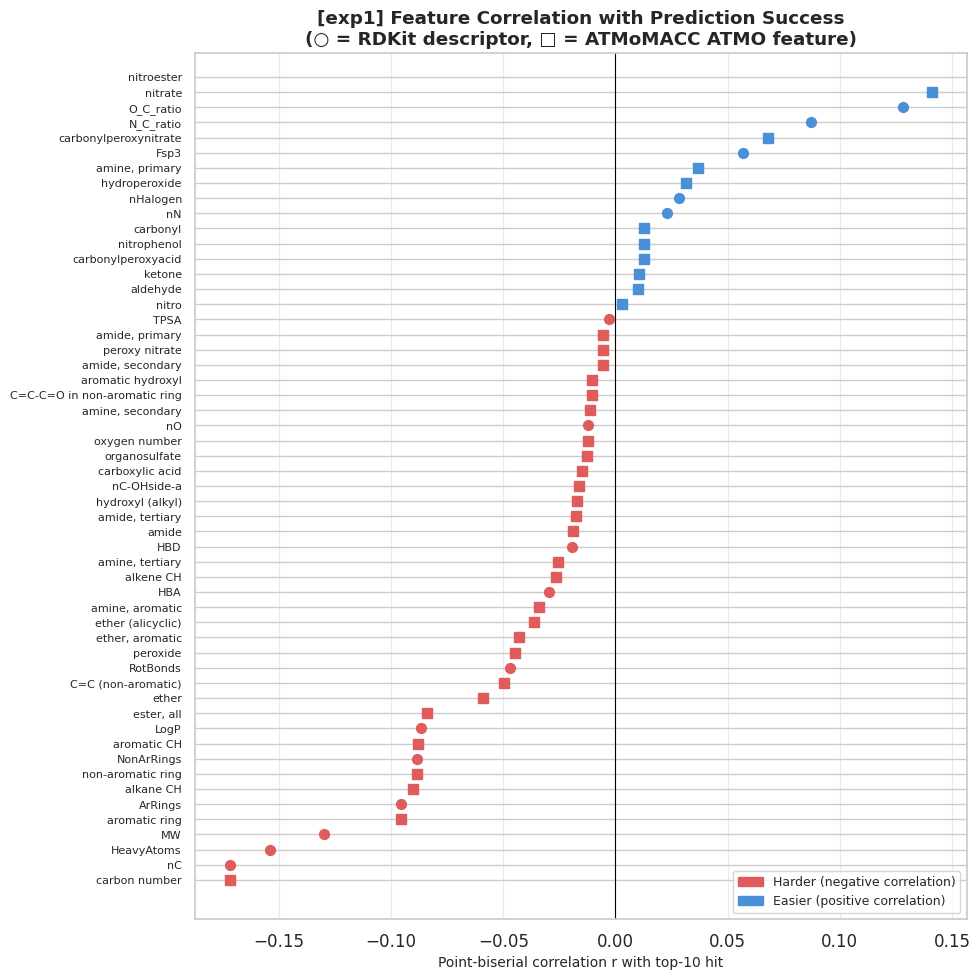


=== exp1 — top negative correlates (hardest features) ===


,Feature,type,r_pb,p-value
52,carbon number,ATMO,-0.1717,0.0000
10,nC,descriptor,-0.1717,0.0000
9,HeavyAtoms,descriptor,-0.1538,0.0000
0,MW,descriptor,-0.1300,0.0000
49,aromatic ring,ATMO,-0.0956,0.0000
6,ArRings,descriptor,-0.0956,0.0000
19,alkane CH,ATMO,-0.0903,0.0000
50,non-aromatic ring,ATMO,-0.0883,0.0000
7,NonArRings,descriptor,-0.0883,0.0000
21,aromatic CH,ATMO,-0.0881,0.0000



=== exp1 — top positive correlates (easiest features) ===


,Feature,type,r_pb,p-value
22,carbonyl,ATMO,0.0129,0.2901
12,nN,descriptor,0.0231,0.0585
13,nHalogen,descriptor,0.0284,0.0204
30,hydroperoxide,ATMO,0.0315,0.0099
16,"amine, primary",ATMO,0.0369,0.0025
8,Fsp3,descriptor,0.0568,0.0000
34,carbonylperoxynitrate,ATMO,0.0678,0.0000
15,N_C_ratio,descriptor,0.0870,0.0000
14,O_C_ratio,descriptor,0.1281,0.0000
32,nitrate,ATMO,0.1409,0.0000


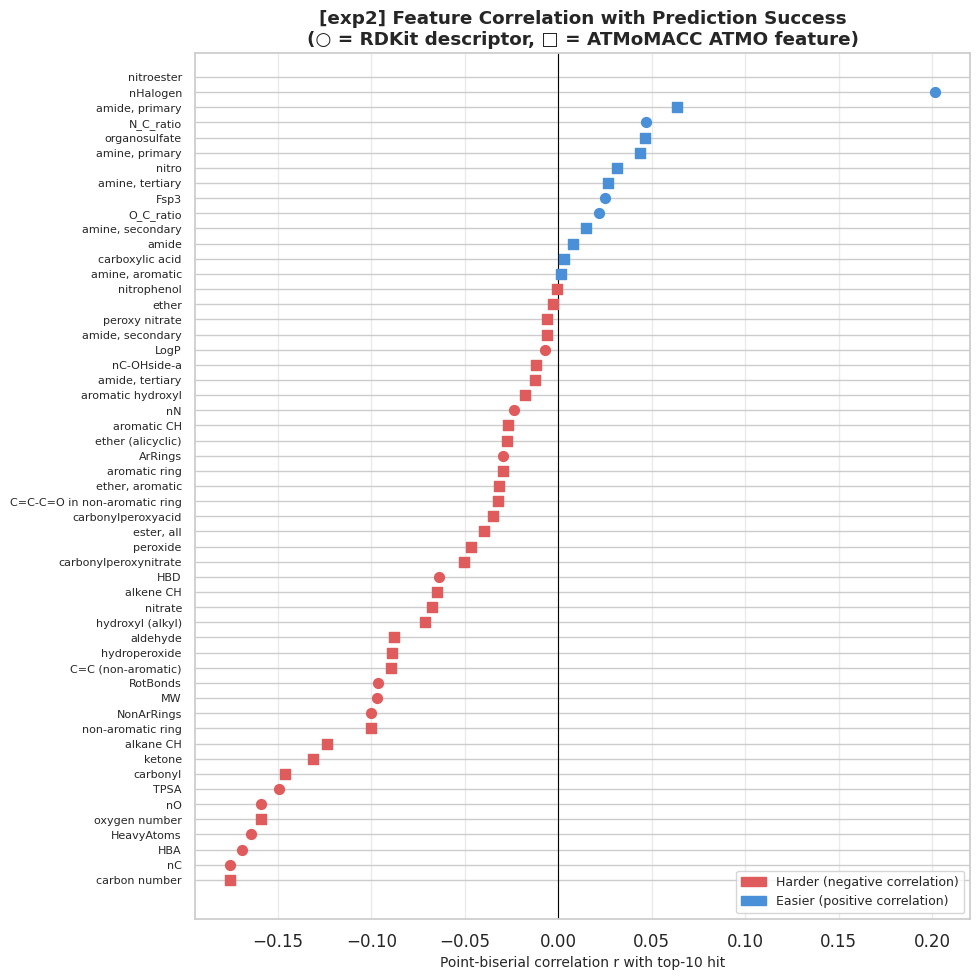


=== exp2 — top negative correlates (hardest features) ===


,Feature,type,r_pb,p-value
52,carbon number,ATMO,-0.1755,0.0
10,nC,descriptor,-0.1755,0.0
4,HBA,descriptor,-0.1694,0.0
9,HeavyAtoms,descriptor,-0.1645,0.0
53,oxygen number,ATMO,-0.1590,0.0
11,nO,descriptor,-0.1590,0.0
2,TPSA,descriptor,-0.1493,0.0
22,carbonyl,ATMO,-0.1460,0.0
35,ketone,ATMO,-0.1311,0.0
19,alkane CH,ATMO,-0.1236,0.0



=== exp2 — top positive correlates (easiest features) ===


,Feature,type,r_pb,p-value
17,"amine, secondary",ATMO,0.0150,0.1919
14,O_C_ratio,descriptor,0.0218,0.0582
8,Fsp3,descriptor,0.0253,0.0280
18,"amine, tertiary",ATMO,0.0264,0.0217
28,nitro,ATMO,0.0314,0.0064
16,"amine, primary",ATMO,0.0437,0.0001
33,organosulfate,ATMO,0.0462,0.0001
15,N_C_ratio,descriptor,0.0472,0.0000
37,"amide, primary",ATMO,0.0634,0.0000
13,nHalogen,descriptor,0.2017,0.0000


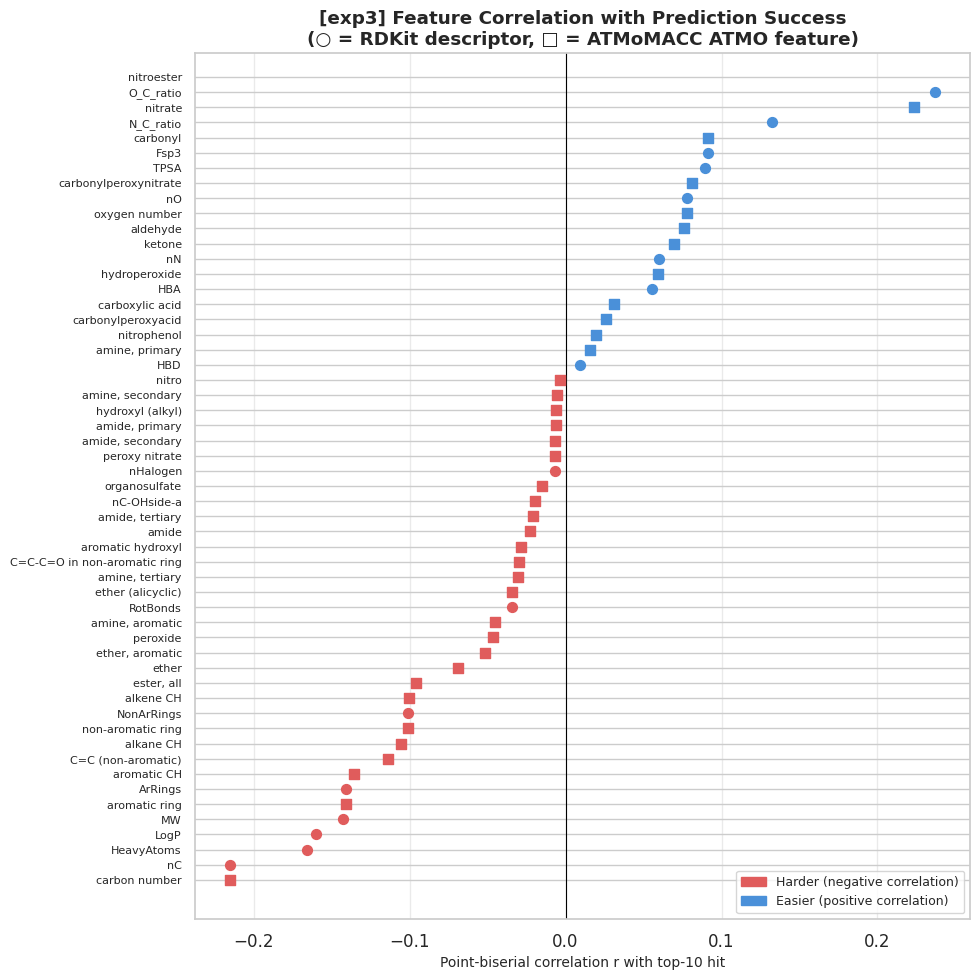


=== exp3 — top negative correlates (hardest features) ===


,Feature,type,r_pb,p-value
52,carbon number,ATMO,-0.2150,0.0
10,nC,descriptor,-0.2150,0.0
9,HeavyAtoms,descriptor,-0.1656,0.0
1,LogP,descriptor,-0.1598,0.0
0,MW,descriptor,-0.1427,0.0
49,aromatic ring,ATMO,-0.1405,0.0
6,ArRings,descriptor,-0.1405,0.0
21,aromatic CH,ATMO,-0.1357,0.0
47,C=C (non-aromatic),ATMO,-0.1139,0.0
19,alkane CH,ATMO,-0.1058,0.0



=== exp3 — top positive correlates (easiest features) ===


,Feature,type,r_pb,p-value
36,aldehyde,ATMO,0.0760,0.0
53,oxygen number,ATMO,0.0778,0.0
11,nO,descriptor,0.0778,0.0
34,carbonylperoxynitrate,ATMO,0.0812,0.0
2,TPSA,descriptor,0.0895,0.0
8,Fsp3,descriptor,0.0916,0.0
22,carbonyl,ATMO,0.0916,0.0
15,N_C_ratio,descriptor,0.1325,0.0
32,nitrate,ATMO,0.2232,0.0
14,O_C_ratio,descriptor,0.2370,0.0


In [27]:
exp_corr_dfs = {}

for exp_name, adf in exp_dfs.items():
    hit_label = adf['hit_top10'].astype(float).values
    corr_rows = []
    for feat in desc_cols + atmo_feat_names:
        vals = adf[feat].fillna(0).values.astype(float)
        r, pval = stats.pointbiserialr(hit_label, vals)
        corr_rows.append({'Feature': feat, 'r_pb': r, 'p-value': pval,
                          'type': 'descriptor' if feat in desc_cols else 'ATMO'})

    corr_df = pd.DataFrame(corr_rows).sort_values('r_pb')
    exp_corr_dfs[exp_name] = corr_df

    fig, ax = plt.subplots(figsize=(10, 10))
    for i, (_, row) in enumerate(corr_df.iterrows()):
        ax.scatter(row['r_pb'], i,
                   color=('#e05c5c' if row['r_pb'] < 0 else '#4a90d9'),
                   marker='o' if row['type'] == 'descriptor' else 's', s=50, zorder=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(range(len(corr_df)))
    ax.set_yticklabels(corr_df['Feature'], fontsize=8)
    ax.set_xlabel('Point-biserial correlation r with top-10 hit', fontsize=10)
    ax.set_title(f'[{exp_name}] Feature Correlation with Prediction Success\n'
                 f'(\u25cb = RDKit descriptor, \u25a1 = ATMoMACC ATMO feature)', fontweight='bold')
    ax.grid(axis='x', alpha=0.4)
    ax.legend(handles=[
        mpatches.Patch(color='#e05c5c', label='Harder (negative correlation)'),
        mpatches.Patch(color='#4a90d9', label='Easier (positive correlation)'),
    ], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'\n=== {exp_name} \u2014 top negative correlates (hardest features) ===')
    display(corr_df[corr_df['r_pb'] < 0].head(15)[['Feature', 'type', 'r_pb', 'p-value']].round(4))
    print(f'\n=== {exp_name} \u2014 top positive correlates (easiest features) ===')
    display(corr_df[corr_df['r_pb'] > 0].tail(10)[['Feature', 'type', 'r_pb', 'p-value']].round(4))

In [28]:
for exp_name in exp_dfs:
    exp_corr_dfs[exp_name].to_csv(f'results_{exp_name}_feature_difficulty.csv', index=False)
    exp_kmeans_results[exp_name]['cluster_summary'].to_csv(f'results_{exp_name}_cluster_summary.csv')
    print(f'Saved results for {exp_name}')

Saved results for exp1
Saved results for exp2
Saved results for exp3
